# ACE Analysis: Temporal-Semantic Heatmaps and Persona Profiling


In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

pd.set_option('display.max_columns', 500)
# disable warnings in ipython
import warnings

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import math

# aether
import rasterio


# # Set the primary sans-serif font to Arial
# sns.set_theme(rc={
#     'font.family': 'sans-serif', 
#     'font.sans-serif': ['Arial']
# })
from shapely.geometry import box
import textwrap


## Config

In [2]:
city = "london"  # {"london", "singapore"}
str_study_period = "20250210_20250223"
loc_embed_type = "aether"

if city == "london":
    proj_crs = "EPSG:27700"
elif city == "singapore":
    proj_crs = "EPSG:3414"

# ACE experiment config. Set experiment_name explicitly to analyse a specific run;
# otherwise the latest experiment with clustering results is used.
ace_save_dir = Path("pretrained_ace") / f"{city}_{loc_embed_type}"
# experiment_name = "20260525_002940_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1"
experiment_name = "20260525_180711_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1"
# experiment_name = "original"

# Clustering embedding config. Load both because downstream analysis compares weekday and weekend patterns.
clustering_embedding_types = ["weekday", "weekend"]

def resolve_experiment_dir(save_dir, experiment_name=None, city="london", loc_embed_type="aether"):
    save_dir = Path(save_dir)
    experiments_dir = save_dir / "experiments"

    if experiment_name is not None:
        experiment_dir = experiments_dir / experiment_name
        if not experiment_dir.exists():
            raise FileNotFoundError(f"Could not find ACE experiment directory at {experiment_dir}")
        return experiment_dir

    candidates = sorted(
        experiments_dir.glob("*/clustering/clustering_metadata_*.json"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if candidates:
        return candidates[0].parents[1]

    legacy_path = next(save_dir.glob("user_clustering_results_*.csv"), None)
    if legacy_path is not None and legacy_path.exists():
        print(f"Using legacy clustering result path: {legacy_path}")
        return save_dir

    raise FileNotFoundError(
        f"No clustering results found under {experiments_dir} or legacy path {legacy_path}. "
        "Run 03_clustering.ipynb first, or set experiment_name explicitly."
    )

def load_clustering_metadata(experiment_dir, embedding_type):
    metadata_path = (
        Path(experiment_dir)
        / "clustering"
        / f"clustering_metadata_{embedding_type}.json"
    )
    if not metadata_path.exists():
        raise FileNotFoundError(f"Could not find clustering metadata at {metadata_path}")

    with metadata_path.open() as f:
        metadata = json.load(f)

    return metadata, metadata_path

def make_umap_config(metadata):
    return {
        "n_neighbors": metadata["umap_n_neighbors"],
        "min_dist": metadata["umap_min_dist"],
        "n_components": metadata["umap_n_components"],
        "metric": metadata["umap_metric"],
        "random_state": metadata["umap_random_state"],
    }

def make_hdbscan_config(metadata):
    return {
        "min_cluster_size": metadata["hdbscan_min_cluster_size"],
        "min_samples": metadata["hdbscan_min_samples"],
    }

experiment_dir = resolve_experiment_dir(ace_save_dir, experiment_name, city, loc_embed_type)
clustering_metadata_by_type = {}
clustering_metadata_paths = {}
umap_configs = {}
hdbscan_configs = {}

for embedding_type in clustering_embedding_types:
    metadata, metadata_path = load_clustering_metadata(experiment_dir, embedding_type)
    clustering_metadata_by_type[embedding_type] = metadata
    clustering_metadata_paths[embedding_type] = metadata_path
    umap_configs[embedding_type] = make_umap_config(metadata)
    hdbscan_configs[embedding_type] = make_hdbscan_config(metadata)

weekday_umap_config = umap_configs["weekday"]
weekend_umap_config = umap_configs["weekend"]
weekday_hdbscan_config = hdbscan_configs["weekday"]
weekend_hdbscan_config = hdbscan_configs["weekend"]

analysis_fig_dir = experiment_dir / "analysis_figs"
analysis_data_dir = experiment_dir / "analysis_data"
analysis_fig_dir.mkdir(parents=True, exist_ok=True)
analysis_data_dir.mkdir(parents=True, exist_ok=True)

print(f"Using ACE experiment directory: {experiment_dir}")
for embedding_type in clustering_embedding_types:
    print(f"Using {embedding_type} clustering metadata: {clustering_metadata_paths[embedding_type]}")
print(f"Analysis figures will be saved to: {analysis_fig_dir}")


Using ACE experiment directory: pretrained_ace/london_aether/experiments/20260525_180711_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1
Using weekday clustering metadata: pretrained_ace/london_aether/experiments/20260525_180711_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1/clustering/clustering_metadata_weekday.json
Using weekend clustering metadata: pretrained_ace/london_aether/experiments/20260525_180711_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1/clustering/clustering_metadata_weekend.json
Analysis figures will be saved to: pretrained_ace/london_aether/experiments/20260525_180711_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1/analysis_figs


## Helper Function

In [3]:
def get_data_dir_path(target_dir_str="mobility_data"):
    """
    Get data dir by seearching the current directory for the folder named 
    If there is no folder named {target_dir_str}, then search the parrent directory for it.
    Do this until a folder named {target_dir_str} is found or the root directory is reached
    """
    current_dir = os.getcwd()
    target_data_dir = None
    while True:
        if target_dir_str in os.listdir(current_dir):
            target_data_dir = os.path.join(current_dir, target_dir_str)
            break
        else:
            parent_dir = os.path.dirname(current_dir)
            if parent_dir == current_dir:  # Reached the root directory
                print(f"Error: Could not find a folder named '{target_dir_str}' in the current directory or any of its parent directories.")
                break
            current_dir = parent_dir
    return target_data_dir

## 1. Prepare Data

### 1.1. Stays

In [4]:
# Get the stays with sigplaces
stay_data_dir = get_data_dir_path('mobility_data')

stay_data_path = f'{stay_data_dir}/{city}_{str_study_period}_stays_bbox_min2staysperday_{loc_embed_type}.csv.gz'
df_stays = pd.read_csv(stay_data_path)
print(f"Total stays: {len(df_stays)}")

sigplaces_dir = get_data_dir_path('sigplaces_and_home')
sigplaces_with_home_path = f'{sigplaces_dir}/{city}_{str_study_period}_sigplaces_with_home.csv.gz'
df_sigplaces_with_home = pd.read_csv(sigplaces_with_home_path)
print(f"Total significant places with home info: {len(df_sigplaces_with_home)}")

df_stays = pd.merge(df_stays, df_sigplaces_with_home[[ 'user_id', 'significant_place', 'is_home']], on=['user_id', 'significant_place'], how='left')
print(f"Sanity Check: df_stays['significant_place'].isna().sum(): {df_stays['significant_place'].isna().sum()}")

Total stays: 3495967
Total significant places with home info: 937813
Sanity Check: df_stays['significant_place'].isna().sum(): 0


In [5]:
# Now we get the start index of the start time and end time of each stay
# according to 15-minute interval bucketing.
df_stays['start_time'] = pd.to_datetime(df_stays['start_time'])
df_stays['end_time'] = pd.to_datetime(df_stays['end_time'])

start_minutes = df_stays['start_time'].dt.hour * 60 + df_stays['start_time'].dt.minute
end_minutes = df_stays['end_time'].dt.hour * 60 + df_stays['end_time'].dt.minute

df_stays['start_time_bucket'] = (start_minutes // 15).clip(lower=0, upper=95).astype(int)
df_stays['end_time_bucket'] = (end_minutes // 15).clip(lower=0, upper=95).astype(int)

# And get the dictionary of time index to the actual time string (e.g., "08:00", "08:15", ...)
time_idx_to_time_str = {i: f"{(i * 15) // 60:02d}:{(i * 15) % 60:02d}" for i in range(24*4)}
print(time_idx_to_time_str[0])   # 00:00
print(time_idx_to_time_str[5])   # 01:15
print(time_idx_to_time_str[32])  # 08:00

# Create a list of all buckets covered by each stay. If a stay crosses midnight, keep the within-day buckets on both sides.
def get_active_buckets(start_bucket, end_bucket):
    start_bucket = int(start_bucket)
    end_bucket = int(end_bucket)
    if end_bucket >= start_bucket:
        return list(range(start_bucket, end_bucket + 1))
    return list(range(start_bucket, 96)) + list(range(0, end_bucket + 1))

df_stays['active_buckets'] = [
    get_active_buckets(start_bucket, end_bucket)
    for start_bucket, end_bucket in zip(df_stays['start_time_bucket'], df_stays['end_time_bucket'])
]
df_stays


00:00
01:15
08:00


,user_id,start_time,end_time,longitude,latitude,significant_place,row,col,is_home,start_time_bucket,end_time_bucket,active_buckets
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ..."
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 13:52:23,2025-02-18 14:45:13,-0.166586,51.481968,1,2337,3826,NaN,55,59,"[55, 56, 57, 58, 59]"
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 19:43:05,2025-02-18 22:53:39,-0.133383,51.323275,0,4103,4196,True,78,91,"[78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 8..."
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 01:43:03,2025-02-19 10:49:59,-0.133407,51.323269,0,4103,4195,True,6,43,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1..."
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 17:46:28,2025-02-19 22:43:03,-0.133356,51.323277,0,4103,4196,True,71,90,"[71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 8..."
...,...,...,...,...,...,...,...,...,...,...,...,...
3495962,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-22 18:49:56,2025-02-22 21:52:59,-0.032223,51.672417,2,217,5322,NaN,75,87,"[75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 8..."
3495963,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-22 21:58:39,2025-02-22 22:03:14,-0.030292,51.656460,11,394,5343,NaN,87,88,"[87, 88]"
3495964,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-22 22:20:47,2025-02-22 23:38:46,-0.045203,51.624544,0,750,5177,True,89,94,"[89, 90, 91, 92, 93, 94]"
3495965,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 00:01:13,2025-02-23 11:23:11,-0.045215,51.624603,0,749,5177,True,0,45,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


#### Separate weekday and weekend stays

In [6]:
df_stays['is_weekend'] = df_stays['start_time'].dt.weekday >= 5

# The percentage of weekend stays
weekend_stays_percentage = df_stays['is_weekend'].mean() * 100
print(f"Percentage of weekend stays: {weekend_stays_percentage:.2f}%")

df_stays_weekday = df_stays[df_stays['is_weekend'] == False]
df_stays_weekend = df_stays[df_stays['is_weekend'] == True]
print(f"Number of weekday stays: {len(df_stays_weekday)}")
print(f"Number of weekend stays: {len(df_stays_weekend)}")

Percentage of weekend stays: 25.18%
Number of weekday stays: 2615550
Number of weekend stays: 880417


### 1.2. Pre-trained Location Embeddings

In [7]:
file_path = '/home/xlwang/code/2026/AETHER/outputs/geotiffs/london_bd_poi_sem_dist_11_classes_with_probing_prompts_3.tif'
# file_path = '/home/xlwang/code/2026/AETHER/outputs/geotiffs/london_bd_poi_sem_dist_12_classes_with_probing_prompts.tif'

# 2. Open the file and read the data
with rasterio.open(file_path) as src:
    # Read all 11 bands into a single NumPy array
    # Shape will be (bands, height, width)
    distribution_map = src.read()
    
    # You can also extract the spatial metadata if you need it later
    # (e.g., the CRS, transform matrix, or bounding box)
    meta = src.meta
    crs = src.crs
    bounds = src.bounds

# 3. Verify the data loaded correctly
print(f"Data shape: {distribution_map.shape} -> (Bands, Height, Width)")
print(f"Data type: {distribution_map.dtype}")
print(f"Coordinate Reference System (CRS): {crs}")
print(distribution_map[:, 0, 0])  # Print the values of all bands at the top-left pixel for a quick check

Data shape: (11, 4510, 9400) -> (Bands, Height, Width)
Data type: float32
Coordinate Reference System (CRS): EPSG:4326
[2.0627124e-04 7.6544331e-04 2.2205524e-02 2.2104159e-02 3.6664130e-04
 6.9688191e-03 5.8170856e-04 8.8694924e-04 3.0204484e-03 9.4005120e-01
 2.8427602e-03]


In [8]:
rows = df_stays['row'].to_numpy(dtype=int)
cols = df_stays['col'].to_numpy(dtype=int)
if rows.min() < 0 or cols.min() < 0 or rows.max() >= distribution_map.shape[1] or cols.max() >= distribution_map.shape[2]:
    raise IndexError("Some stay raster row/col indices fall outside the semantic distribution map bounds.")

# Vectorised lookup: result is (n_stays, n_semantic_classes).
sem_dists = distribution_map[:, rows, cols].T
df_stays['sem_dist'] = list(sem_dists)

# Keep one enriched copy as the canonical stay table for all downstream filters.
df_stays_all = df_stays.copy()
df_stays_weekday = df_stays_all[df_stays_all['is_weekend'] == False].copy()
df_stays_weekend = df_stays_all[df_stays_all['is_weekend'] == True].copy()
print(f"Added sem_dist to df_stays: {df_stays['sem_dist'].notna().sum():,} rows")


Added sem_dist to df_stays: 3,495,967 rows


### 1.3. Activity-travel Profile Clustering Results

In [9]:
def get_cluster_col_from_metadata(embedding_type, metadata):
    return metadata.get(
        "cluster_col",
        "clst_{embedding_type}_umap{n_components}d_size{min_cluster_size}_sample{min_samples}".format(
            embedding_type=embedding_type,
            n_components=metadata["umap_n_components"],
            min_cluster_size=metadata["hdbscan_min_cluster_size"],
            min_samples=metadata["hdbscan_min_samples"],
        )
    )

cluster_id_col = "cluster_id"
cluster_id_cols = {
    embedding_type: get_cluster_col_from_metadata(embedding_type, metadata)
    for embedding_type, metadata in clustering_metadata_by_type.items()
}
weekday_cluster_id_col = cluster_id_cols["weekday"]
weekend_cluster_id_col = cluster_id_cols["weekend"]
cluster_id_cols


{'weekday': 'clst_weekday_umap5d_size1000_sample300',
 'weekend': 'clst_weekend_umap5d_size2000_sample200'}

In [10]:
# Read user clustering results from the paths saved with each clustering metadata file.
def resolve_clustering_result_path(metadata):
    clustering_result_path = Path(metadata["clustering_results_path"])
    if not clustering_result_path.is_absolute():
        clustering_result_path = Path.cwd() / clustering_result_path

    if not clustering_result_path.exists():
        legacy_clustering_filename = f"user_clustering_results_{city}_{loc_embed_type}.csv"
        legacy_clustering_path = experiment_dir / "clustering" / legacy_clustering_filename
        if legacy_clustering_path.exists():
            clustering_result_path = legacy_clustering_path
        elif (experiment_dir / legacy_clustering_filename).exists():
            clustering_result_path = experiment_dir / legacy_clustering_filename
        else:
            raise FileNotFoundError(f"Could not find clustering results at {clustering_result_path}")

    return clustering_result_path

clustering_result_paths = {
    embedding_type: resolve_clustering_result_path(metadata)
    for embedding_type, metadata in clustering_metadata_by_type.items()
}
df_clustering_res_by_type = {}

for embedding_type, clustering_result_path in clustering_result_paths.items():
    cluster_col = cluster_id_cols[embedding_type]
    print(f"Reading {embedding_type} clustering results from: {clustering_result_path}")
    df_result = pd.read_csv(clustering_result_path)

    required_cols = {"user_id_num", "user_id", cluster_col}
    missing_cols = required_cols - set(df_result.columns)
    if missing_cols:
        raise KeyError(
            f"Missing expected {embedding_type} clustering-result columns: {sorted(missing_cols)}"
        )

    df_result = df_result[["user_id_num", "user_id", cluster_col]].rename(columns={cluster_col: cluster_id_col}).copy()
    df_result.loc[df_result[cluster_id_col] != -1, cluster_id_col] += 1
    df_clustering_res_by_type[embedding_type] = df_result

df_clustering_res_weekday = df_clustering_res_by_type["weekday"]
df_clustering_res_weekend = df_clustering_res_by_type["weekend"]

df_clustering_res_by_type


Reading weekday clustering results from: /home/xlwang/code/2026/ace_dev/pretrained_ace/london_aether/experiments/20260525_180711_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1/clustering/user_clustering_results_london_aether_weekday.csv
Reading weekend clustering results from: /home/xlwang/code/2026/ace_dev/pretrained_ace/london_aether/experiments/20260525_180711_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1/clustering/user_clustering_results_london_aether_weekend.csv


{'weekday':         user_id_num                               user_id  cluster_id
 0                 0  000088cc-b646-409b-a026-69cd9d47b838           1
 1                 2  000135bd-bf0b-4880-af99-1791ce98dddf          -1
 2                 3  00016f95-edc9-4642-a6e6-70ce63b66346          10
 3                 4  0001dfff-15bc-404b-a5f2-a1ec0b458766           9
 4                 7  00026b53-cb9f-4b07-aeb4-8e2aced6bb15          -1
 ...             ...                                   ...         ...
 104706       112107  fffeb333-944f-4663-aea6-f310fe721d03           9
 104707       112108  ffff1696-ce5a-499c-a567-1a9f612ca0c2           1
 104708       112109  ffff1d0a-e065-451c-ab38-61d881dae01f           3
 104709       112110  ffff2a7d-c1e9-4364-a074-59fc733599f6           1
 104710       112111  ffff8ebb-33d5-4851-a36d-12de4548ea2e           2
 
 [104711 rows x 3 columns],
 'weekend':        user_id_num                               user_id  cluster_id
 0                1  0000c

In [11]:
# Explode the lists into separate rows. Always filter from df_stays_all because it contains sem_dist.
required_cols = {'active_buckets', 'sem_dist', 'is_weekend'}
missing_cols = required_cols - set(df_stays_all.columns)
if missing_cols:
    raise KeyError(
        f"df_stays_all is missing {sorted(missing_cols)}. "
        "Re-run the semantic-distribution lookup cell before exploding stays."
    )

# Keep all stays so downstream heatmaps can compare weekday and weekend side by side.
df_stays_for_analysis = df_stays_all.copy()

df_exploded = df_stays_for_analysis.explode('active_buckets').reset_index(drop=True)
df_exploded


,user_id,start_time,end_time,longitude,latitude,significant_place,row,col,is_home,start_time_bucket,end_time_bucket,active_buckets,is_weekend,sem_dist
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,7,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,8,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,9,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,10,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,11,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55720559,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,749,5178,True,52,94,90,True,"[0.42573082, 0.018511064, 0.10884766, 0.011518..."
55720560,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,749,5178,True,52,94,91,True,"[0.42573082, 0.018511064, 0.10884766, 0.011518..."
55720561,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,749,5178,True,52,94,92,True,"[0.42573082, 0.018511064, 0.10884766, 0.011518..."
55720562,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,749,5178,True,52,94,93,True,"[0.42573082, 0.018511064, 0.10884766, 0.011518..."


In [12]:
# Have a look at the average semantic distribution across all stays and time buckets.
if 'sem_dist' not in df_exploded.columns:
    raise KeyError("df_exploded has no sem_dist column. Re-run cells 13, 14, and 18 in order.")

df_exploded['sem_dist'].mean()

# array([0.18760011, 0.02414187, 0.05807045, 0.07276071,
#        0.09249941, 0.04832468, 0.02883168, 0.06688748, 0.07840447,
#        0.10665883])


array([0.18760011, 0.02414187, 0.05807045, 0.05087754, 0.07276071,
       0.09249941, 0.04832468, 0.02883168, 0.06688748, 0.07840447,
       0.10665883])

## 2. Plot Heatmaps

In [13]:
from pprint import pprint

list_semantics = ['Residential and Housing',
    'Commercial and Business',
    'Industrial and Manufacturing',
    'Education and Schools',
    'Grocery and Convenience',
    'Medical and Healthcare',
    'Eating and Drinking',
    'Shopping and Retail',
    'Entertainment, Arts and Culture',
    'Parks and Greenspace',
    # 'Civic, Governmental, and Public Facilities',
    'Transport and Transit']

list_semantics = [s.replace(' ', '_') for s in list_semantics]
# replace "," with ""
list_semantics = [s.replace(',', '') for s in list_semantics]

list_semantics_short = ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']
dict_sem_short_to_long = dict(zip(list_semantics_short, list_semantics))
pprint(dict_sem_short_to_long)


# ==========================================
# Compute Cluster Sizes (number of people)
# ==========================================
def get_cluster_user_counts(df_clustering_res_i, embedding_type):
    counts = (
        df_clustering_res_i.dropna(subset=[cluster_id_col])
        .groupby(cluster_id_col)['user_id']
        .nunique()
        .to_dict()
    )
    if -1 in counts:
        print(f"Excluding {embedding_type} outlier cluster with ID -1 and user count {counts[-1]} from total user count.")
        counts = {k: v for k, v in counts.items() if k != -1}
    return counts

cluster_user_counts_by_type = {
    embedding_type: get_cluster_user_counts(df_clustering_res_i, embedding_type)
    for embedding_type, df_clustering_res_i in df_clustering_res_by_type.items()
}
weekday_cluster_user_counts = cluster_user_counts_by_type["weekday"]
weekend_cluster_user_counts = cluster_user_counts_by_type["weekend"]
cluster_user_counts_by_type


{'CB': 'Commercial_and_Business',
 'EAC': 'Entertainment_Arts_and_Culture',
 'ED': 'Eating_and_Drinking',
 'ES': 'Education_and_Schools',
 'GC': 'Grocery_and_Convenience',
 'IM': 'Industrial_and_Manufacturing',
 'MH': 'Medical_and_Healthcare',
 'PG': 'Parks_and_Greenspace',
 'RH': 'Residential_and_Housing',
 'SR': 'Shopping_and_Retail',
 'TT': 'Transport_and_Transit'}
Excluding weekday outlier cluster with ID -1 and user count 39996 from total user count.
Excluding weekend outlier cluster with ID -1 and user count 17623 from total user count.


{'weekday': {1: 3416,
  2: 1906,
  3: 19703,
  4: 4028,
  5: 7798,
  6: 2568,
  7: 2678,
  8: 1585,
  9: 3019,
  10: 18014},
 'weekend': {1: 43900, 2: 18714, 3: 2856}}

### Helper Functions

In [14]:
def explode_sem_dist_2_columns(df, list_semantics, sem_dist_col='sem_dist'):
    """
    Explode the 'sem_dist' column (which contains lists) into separate columns with names based on the provided prefix.
    
    Parameters:
    - df: The input DataFrame containing the 'sem_dist' column.
    - list_semantics: A list of strings representing the names for the new columns.
    - sem_dist_col: The name of the column containing the semantic distributions (default is 'sem_dist').
    
    Returns:
    - A new DataFrame with the original columns (except 'sem_dist') and new columns for each semantic category.
    """
    # Create a new DataFrame directly from the lists in 'sem_dist'
    expanded_semantics = pd.DataFrame(df[sem_dist_col].tolist(), columns=list_semantics, index=df.index)
    
    # Combine the new columns with your original DataFrame
    # We drop the old 'sem_dist' column
    df_combined = pd.concat([df.drop(columns=[sem_dist_col]), expanded_semantics], axis=1)
    
    return df_combined


def min_max_normalise_act_pattern(df, list_semantics, norm_by_col_name, normalise_by='cluster', axis=0):
    """
    Min-Max normalise the activity pattern along the specified axis (0 for columns, 1 for rows, 2 for global per group).
    If normalise_by is 'individual', we normalise the activity pattern of each individual.
    If normalise_by is 'cluster', we normalise the activity pattern of each cluster, which will require that we have 
    aggregated the activity pattern at the cluster level. For example, by summing up the semantic distributions of all activities.
    """
    df_normed = df.copy()

    print(f"Normalising by {normalise_by} along axis {axis} for columns: {list_semantics}")

    if axis == 0:
        # Fully vectorised min-max scaling along columns (per group)
        grouped = df_normed.groupby(norm_by_col_name)[list_semantics]
        group_min = grouped.transform('min')
        group_max = grouped.transform('max')
        
        # Calculate the range (max - min)
        group_range = group_max - group_min
        
        # Replace 0 ranges with 1 to prevent division by zero. 
        # The numerator will be 0, so the final result becomes 0 (mimicking your original logic).
        group_range = group_range.replace(0, 1)
        df_normed[list_semantics] = (df_normed[list_semantics] - group_min) / group_range
        
    elif axis == 1:
        # Min-Max normalisation along rows (inherently individual to each row)
        # 1. Find the min and max for each individual row
        row_min = df_normed[list_semantics].min(axis=1)
        row_max = df_normed[list_semantics].max(axis=1)
        
        # 2. Calculate the range for each row
        row_range = row_max - row_min
        
        # 3. Prevent division by zero if all values in a row are identical
        row_range = row_range.replace(0, 1)
        
        # 4. Apply the formula: (value - min) / range
        # We must use .sub() and .div() with axis=0 to ensure Pandas aligns the math correctly
        df_normed[list_semantics] = (
            df_normed[list_semantics]
            .sub(row_min, axis=0)
            .div(row_range, axis=0)
        )
        
    elif axis == 2:
        # Global min-max normalisation (per group)
        # We find a single min and max across ALL specified columns for each distinct group.
        
        # 1. First, find the minimum and maximum of each row across the semantic columns
        row_mins = df_normed[list_semantics].min(axis=1)
        row_maxs = df_normed[list_semantics].max(axis=1)
        
        # 2. Group those row extremums by your grouping column to find the true global min/max for that group
        group_global_min = row_mins.groupby(df_normed[norm_by_col_name]).transform('min')
        group_global_max = row_maxs.groupby(df_normed[norm_by_col_name]).transform('max')
        
        # 3. Calculate the global range for the group and prevent division by zero
        group_global_range = group_global_max - group_global_min
        group_global_range = group_global_range.replace(0, 1)
        
        # 4. Apply the normalisation, aligning by the row index (axis=0)
        df_normed[list_semantics] = (
            df_normed[list_semantics]
            .sub(group_global_min, axis=0)
            .div(group_global_range, axis=0)
        )
        
    else:
        raise ValueError("axis must be 0 (columns), 1 (rows), or 2 (global).")

    return df_normed


def global_min_max_normalise_act_pattern(df, list_semantics):
    """
    Applies global Min-Max normalisation across the entire dataset for the specified columns.
    Uses a single global minimum and global maximum to scale all values.
    
    Parameters:
    - df: The pandas DataFrame containing the data.
    - list_semantics: A list of column names (strings) to be normalised.
    
    Returns:
    - A new DataFrame with the specified columns normalised to a 0-1 scale.
    """
    df_normed = df.copy()

    print(f"Applying global normalisation across columns: {list_semantics}")

    # 1. Find the absolute global minimum and maximum across all specified columns
    global_min = df_normed[list_semantics].min().min()
    global_max = df_normed[list_semantics].max().max()

    # 2. Calculate the global range
    global_range = global_max - global_min

    # 3. Prevent division by zero in the rare case that all values in the dataset are identical
    if global_range == 0:
        global_range = 1

    # 4. Apply the normalisation formula
    # Pandas will automatically broadcast this scalar operation across all rows and specified columns
    df_normed[list_semantics] = (df_normed[list_semantics] - global_min) / global_range

    return df_normed


# Function to plot the heatmaps for each cluster's behaviour pattern across time and semantics
def plot_cluster_grid(df_cluster_pattern, title, 
                      cluster_col_name, list_semantics, 
                      time_bucket_col_name='active_buckets', cluster_user_counts=None,
                      n_rows=4, n_cols=3, cmap='YlOrRd',
                      if_save_fig=False, save_fig_path=None,
                      is_residual=False):
    
    cluster_user_counts = cluster_user_counts or {}
    total_num_users = sum(cluster_user_counts.values())
    clusters = sorted([c for c in df_cluster_pattern[cluster_col_name].dropna().unique().tolist() if c != -1])
    
    # We only keep the first word in the pre-defined semantics list for better readability
    list_semantics = [semantics.split()[0] for semantics in list_semantics]

    # Since time is now on the x-axis, the figure needs to be wider rather than taller
    fig_w = 7 * n_cols
    fig_h = 3 * n_rows
    
    # Removed sharex and sharey to keep the original independent axis style
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    axes = np.atleast_1d(axes).ravel()

    # ---------------------------------------------------------
    # THE SWITCH LOGIC: Determine min, max, and colour bar centre
    # ---------------------------------------------------------
    if is_residual:
        # For deviations: symmetric limits around zero
        max_abs_val = df_cluster_pattern[list_semantics].abs().max().max()
        global_min = -max_abs_val
        global_max = max_abs_val
        heatmap_center = 0
    else:
        # For normal intensities: true min and max
        global_min = df_cluster_pattern[list_semantics].min().min()
        global_max = df_cluster_pattern[list_semantics].max().max()
        heatmap_center = None
    
    # # Calculate global min and max for the shared colour bar
    # global_min = df_cluster_pattern[list_semantics].min().min()
    # global_max = df_cluster_pattern[list_semantics].max().max()

    for i, cluster in enumerate(clusters):
        ax = axes[i]
        
        # Ensure all 96 15-minute buckets exist
        cluster_data = (
            df_cluster_pattern[df_cluster_pattern[cluster_col_name] == cluster]
            .set_index(time_bucket_col_name)[list_semantics]
            .reindex(range(96))
            .fillna(0)
        )
        
        # Transpose the data: semantics become the index (y-axis) and time becomes the columns (x-axis)
        cluster_data_t = cluster_data.T

        sns.heatmap(
            cluster_data_t,
            cmap=cmap,
            ax=ax,
            cbar=False,       # Turn off individual colour bars
            vmin=global_min, 
            vmax=global_max,
            center=heatmap_center,
            linewidths=0.01,
            linecolor='white'
        )

        # Define the exact positions for the x-axis ticks (every 8 columns)
        tick_positions = [j + 0.5 for j in range(0, 96, 8)]
        tick_labels = [f"{int(j/4):02d}:00" for j in range(0, 96, 8)]
        
        # Apply ticks to the x-axis
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=0)
        
        # Restore the original tick parameters and font sizes
        ax.tick_params(axis='y', labelsize=7) 
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='x', pad=0)

        n_people = int(cluster_user_counts.get(cluster, 0))
        pct_people = n_people / total_num_users * 100 if total_num_users > 0 else 0
        ax.set_title(f'Cluster {cluster} (n={n_people}, {pct_people:.2f}%)', fontsize=9)

        # Restore the original blank labels
        ax.set_xlabel('')
        ax.set_ylabel('')

    # Clean up any empty subplots if you have fewer clusters than grid spaces
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Format the figure layout leaving space at the top
    plt.suptitle(title, fontsize=12, y=0.98, 
                #  ha='left', x=0.25
                 ) 
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 

    # Add the Figure-Level Colour Bar
    cbar_ax = fig.add_axes([0.83, 0.945, 0.15, 0.01]) 
    
    # Grab the visual map from the very first heatmap to use as a reference
    mappable = axes[0].collections[0]
    
    # Draw the colour bar horizontally
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=6) 
    cbar.set_label('Visitation Intensity', fontsize=7, labelpad=2)

    if if_save_fig and save_fig_path:
        save_fig_path = Path(save_fig_path)
        save_fig_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_fig_path, bbox_inches='tight', dpi=400)
    plt.show()

### 2.1. The Overall Pattern of Semantic Distribution Across Time Buckets

In [15]:
df_exploded['user_id'].nunique()

112112

In [16]:
if 'sem_dist' not in df_exploded.columns:
    raise KeyError("df_exploded has no sem_dist column. Re-run cells 13, 14, and 18 in order.")

tmp = df_exploded[df_exploded['is_weekend'] == False]
weekday_overall_behaviour_pattern = tmp.groupby('active_buckets', as_index=False)['sem_dist'].sum()

tmp = df_exploded[df_exploded['is_weekend'] == True]
weekend_overall_behaviour_pattern = tmp.groupby('active_buckets', as_index=False)['sem_dist'].sum()


In [17]:
weekday_overall_behaviour_pattern = explode_sem_dist_2_columns(weekday_overall_behaviour_pattern, list_semantics_short, sem_dist_col='sem_dist')
weekend_overall_behaviour_pattern = explode_sem_dist_2_columns(weekend_overall_behaviour_pattern, list_semantics_short, sem_dist_col='sem_dist')

In [18]:
weekday_overall_behaviour_pattern

,active_buckets,RH,CB,IM,ES,GC,MH,ED,SR,EAC,PG,TT
0,0,65714.976562,7489.125977,16826.931641,15421.175781,23673.066406,29599.412109,15183.285156,7903.277832,21006.025391,23927.687500,33926.492188
1,1,89931.328125,10283.486328,22856.679688,21152.814453,32613.882812,40840.078125,20944.796875,10826.838867,28757.685547,33110.808594,46275.820312
2,2,97538.242188,11174.376953,24623.339844,23003.392578,35467.050781,44423.410156,22819.990234,11761.631836,31262.623047,36106.589844,50013.441406
3,3,101400.085938,11630.349609,25522.908203,23983.833984,36916.972656,46279.320312,23794.669922,12237.449219,32586.970703,37621.878906,51964.203125
4,4,103006.617188,11815.173828,25921.203125,24408.832031,37488.679688,47055.496094,24194.054688,12432.398438,33161.332031,38275.125000,52819.281250
...,...,...,...,...,...,...,...,...,...,...,...,...
91,91,110961.546875,12697.622070,27721.138672,26038.060547,40369.679688,50607.046875,26054.287109,13429.172852,35707.734375,40550.109375,57233.949219
92,92,104818.429688,11922.607422,26073.746094,24508.750000,38068.894531,47613.757812,24466.945312,12571.195312,33584.871094,38144.707031,53974.589844
93,93,98509.828125,11167.781250,24616.708984,22961.976562,35632.558594,44630.605469,22891.427734,11742.958008,31413.259766,35799.265625,50772.152344
94,94,91542.648438,10397.627930,23178.007812,21358.203125,32966.414062,41313.210938,21226.134766,10918.230469,29160.494141,33149.781250,47276.128906


In [19]:
weekend_overall_behaviour_pattern

,active_buckets,RH,CB,IM,ES,GC,MH,ED,SR,EAC,PG,TT
0,0,24368.767578,2775.431396,6147.825195,5720.956543,8673.594727,10897.265625,5713.386719,2933.340088,7919.989746,8881.904297,12523.851562
1,1,33177.625000,3792.419434,8312.518555,7839.724609,11927.312500,14980.499023,7839.666016,3994.768311,10795.928711,12235.657227,17021.451172
2,2,35917.660156,4128.107422,8948.335938,8527.813477,12989.308594,16313.968750,8556.666016,4349.382324,11748.979492,13292.889648,18392.980469
3,3,37355.714844,4294.467285,9246.607422,8865.680664,13531.510742,16986.900391,8909.536133,4523.485352,12230.880859,13816.056641,19078.951172
4,4,37993.738281,4370.354980,9392.779297,9026.604492,13752.428711,17284.201172,9063.637695,4593.680664,12455.307617,14079.678711,19412.550781
...,...,...,...,...,...,...,...,...,...,...,...,...
91,91,40385.507812,4628.932617,9752.307617,9506.364258,14658.960938,18357.939453,9600.290039,4906.478516,13152.977539,14722.280273,20701.527344
92,92,37758.015625,4300.404297,9105.430664,8859.287109,13660.283203,17083.625000,8925.876953,4536.304688,12238.873047,13733.846680,19327.333984
93,93,36188.414062,4128.675781,8868.007812,8525.583984,13056.516602,16379.532227,8519.419922,4351.339355,11703.654297,13229.084961,18621.996094
94,94,33503.437500,3835.984863,8331.491211,7893.688477,12026.384766,15094.188477,7889.905762,4053.600830,10848.586914,12242.016602,17301.878906


In [20]:
# Plot subplots of (1, 2) heatmaps for weekday vs weekend overall behaviour pattern
list_day_type = ['Weekday', 'Weekend']
list_overall_behaviour_pattern = [weekday_overall_behaviour_pattern, weekend_overall_behaviour_pattern]

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_behaviour_heatmaps(list_overall_behaviour_pattern, list_day_type, norm_along='time', figsize=(10, 8), cmap="YlOrRd", if_save_fig=False, save_fig_path=None):
    """
    Plots a series of transposed normalised heatmaps for different day types (Time on X-axis).
    
    Parameters:
    - list_overall_behaviour_pattern: List of pandas DataFrames containing the heatmap data.
    - list_day_type: List of strings representing the day types (e.g., ['Weekday', 'Weekend']).
    - norm_along: String, either 'time', 'semantics', or 'global'. Determines the axis along which to normalise.
    - figsize: Tuple representing the figure size. Adjusted default for 2x1 layout.
    - cmap: String representing the seaborn colour map. Default is 'YlOrRd'.
    - if_save_fig: Boolean indicating whether to save the figure.
    - save_fig_path: String representing the path where the figure will be saved.   
    """
    num_plots = len(list_day_type)
    
    # 1. Change layout to num_plots rows, 1 column
    fig, axes = plt.subplots(num_plots, 1, figsize=figsize)
    
    # Ensure axes is a flat array even for a single plot
    axes = np.atleast_1d(axes).ravel()

    for idx, day_type in enumerate(list_day_type):
        ax = axes[idx]
        print(f"Plotting the {idx}-th heatmap with day type: {day_type}")
        
        df_heatmap = list_overall_behaviour_pattern[idx].set_index('active_buckets')
        
        # --- Normalisation Logic ---
        if norm_along == 'time':
            # Normalises each semantic category across all time buckets
            denom = (df_heatmap.max(axis=0) - df_heatmap.min(axis=0)).replace(0, 1)
            df_norm = (df_heatmap - df_heatmap.min(axis=0)) / denom
            plot_title = f"{day_type} Overall Pattern Normalised along Time Axis"
            
        elif norm_along == 'semantics':
            # Normalises each time bucket across all semantic categories
            row_min = df_heatmap.min(axis=1)
            row_max = df_heatmap.max(axis=1)
            denom = (row_max - row_min).replace(0, 1)
            df_norm = df_heatmap.sub(row_min, axis=0).div(denom, axis=0)
            plot_title = f"{day_type} Overall Pattern Normalised along Semantics Axis"
            
        elif norm_along == 'global':
            # Normalises using a single dataset-wide scale
            global_min = df_heatmap.min().min()
            global_max = df_heatmap.max().max()
            denom = global_max - global_min
            if denom == 0:
                denom = 1
            df_norm = (df_heatmap - global_min) / denom
            plot_title = f"{day_type} Overall Pattern Normalised using Global Scale"
            
        else:
            raise ValueError("norm_along must be either 'time', 'semantics', or 'global'.")

        # 2. Transpose the normalised dataframe for plotting (Semantics -> Y, Time -> X)
        df_norm_t = df_norm.T

        # --- Plotting and Formatting ---
        sns.heatmap(df_norm_t,
                    ax=ax,
                    cbar=False, # Turn off individual colour bars
                    cmap=cmap,
                    # linewidths=0.01,
                    # linecolor='white'
                    )
        
        # 3. Apply custom X-axis ticks and labels (since time is now on the X-axis)
        tick_positions = [i + 0.5 for i in range(0, 96, 4)]
        tick_labels = [f"{int(i/4):02d}:00" for i in range(0, 96, 4)]
        
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=0)
        
        # Ensure Y-axis semantic labels are horizontal and readable
        ax.tick_params(axis='y', labelsize=8, labelrotation=0) 
        ax.tick_params(axis='x', labelsize=8)
        
        ax.set_title(plot_title, fontsize=10, pad=8)
        ax.set_ylabel('')
        ax.set_xlabel('')
        # ax.set_xlabel('Time' if idx == num_plots - 1 else '') # Only add X label to the bottom plot

    # 4. Format layout to make room for the shared colour bar at the top
    plt.tight_layout(rect=[0, 0, 1, 0.93]) 

    # 5. Add the Figure-Level Shared Colour Bar (Top-Right)
    # [left, bottom, width, height] as fractions of the figure
    cbar_ax = fig.add_axes([0.75, 0.95, 0.20, 0.010]) 
    
    # Grab the visual map from the very first heatmap to use as a reference
    mappable = axes[0].collections[0]
    
    # Draw the colour bar horizontally
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=7) 
    cbar.set_label('Normalised Intensity', fontsize=8, labelpad=4)
    if if_save_fig and save_fig_path:
        save_fig_path = Path(save_fig_path)
        save_fig_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_fig_path, bbox_inches='tight', dpi=400)
    plt.show()

Plotting the 0-th heatmap with day type: Weekday
Plotting the 1-th heatmap with day type: Weekend


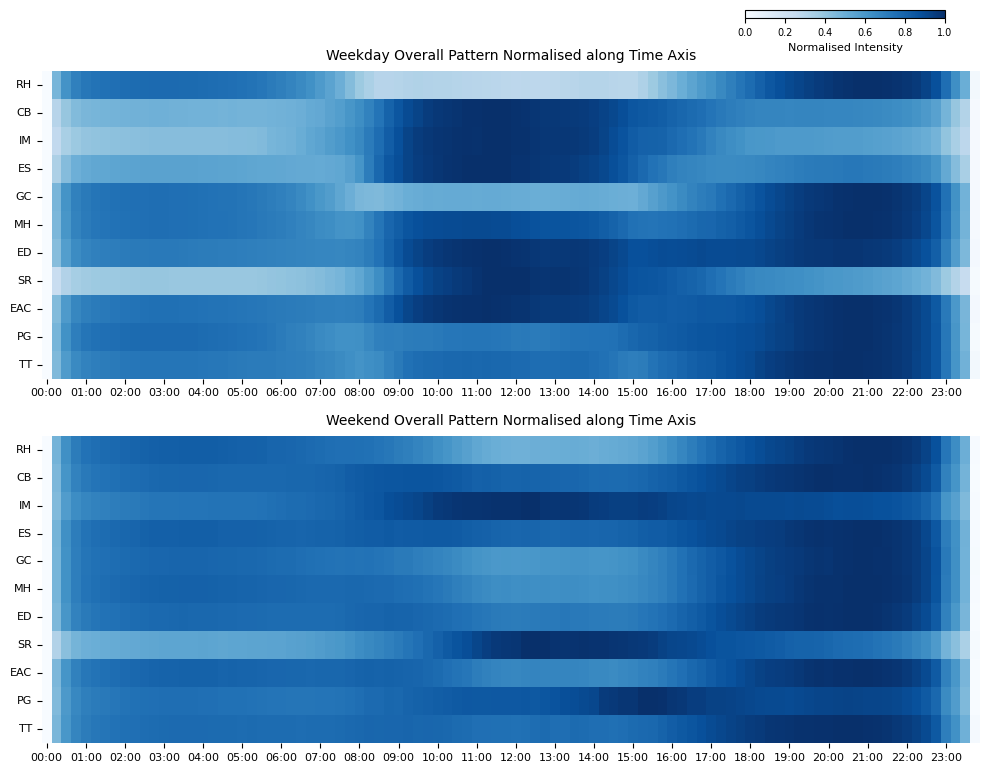

In [21]:
plot_behaviour_heatmaps(
    list_overall_behaviour_pattern, 
    list_day_type, 
    norm_along='time',
    cmap="Blues",
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'overall_act_pattern_tnorm.png'
)

Plotting the 0-th heatmap with day type: Weekday
Plotting the 1-th heatmap with day type: Weekend


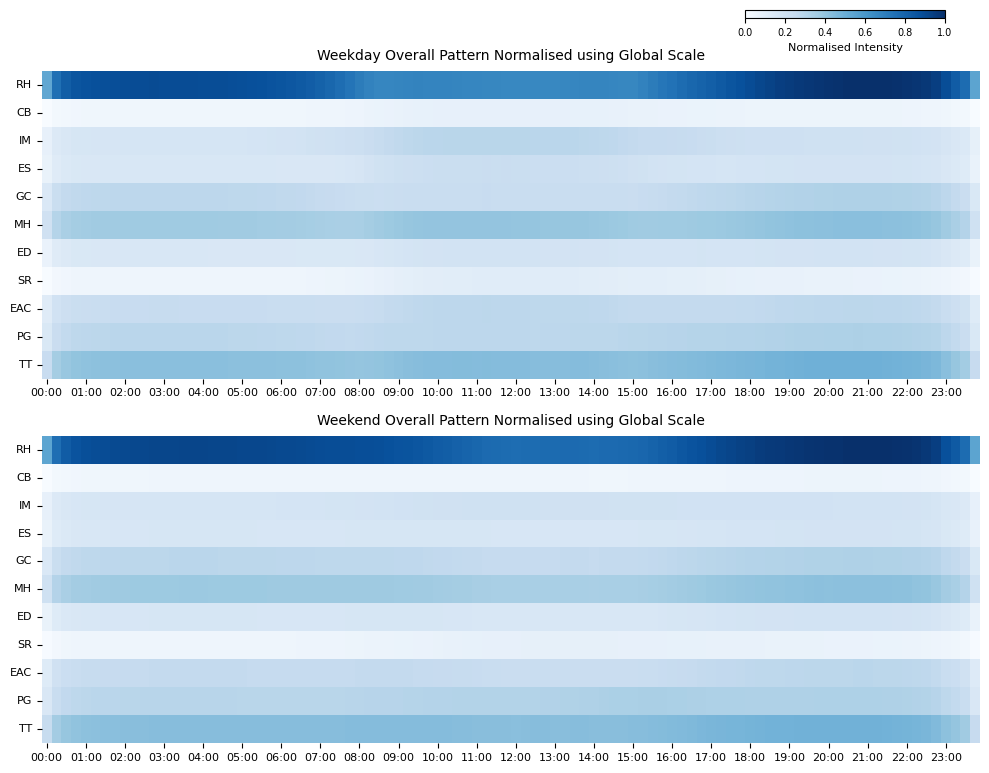

In [22]:
plot_behaviour_heatmaps(list_overall_behaviour_pattern, 
                        list_day_type, 
                        norm_along='global',
                        cmap='Blues',
                        if_save_fig=True,
                        save_fig_path=analysis_fig_dir / 'overall_act_pattern_globalnorm.png'
                        )

### 2.2. The Patterns of Each Cluster

#### Helper Functions for Normalisation and Plotting

In [ ]:
# # Normalise the cluster activity pattern along the column or row
# def normalise_cluster_pattern(df, cluster_col_name, list_semantics, axis=0):
#     df_normed = df.copy()
    
#     if axis == 0:
#         # Fully vectorised min-max scaling
#         grouped = df_normed.groupby(cluster_col_name)[list_semantics]
#         group_min = grouped.transform('min')
#         group_max = grouped.transform('max')
#         # Calculate the range (max - min)
#         group_range = group_max - group_min
#         # Replace 0 ranges with 1 to prevent division by zero. 
#         # The numerator will be 0, so the final result becomes 0 (mimicking your original logic).
#         group_range = group_range.replace(0, 1)
#         df_normed[list_semantics] = (df_normed[list_semantics] - group_min) / group_range

#     else:
#         # Min-Max normalisation along rows
#         # 1. Find the min and max for each individual row
#         row_min = df_normed[list_semantics].min(axis=1)
#         row_max = df_normed[list_semantics].max(axis=1)
        
#         # 2. Calculate the range for each row
#         row_range = row_max - row_min
        
#         # 3. Prevent division by zero if all values in a row are identical
#         row_range = row_range.replace(0, 1)
        
#         # 4. Apply the formula: (value - min) / range
#         # We must use .sub() and .div() with axis=0 to ensure Pandas aligns the math correctly
#         df_normed[list_semantics] = (
#             df_normed[list_semantics]
#             .sub(row_min, axis=0)
#             .div(row_range, axis=0)
#         )
        
#     return df_normed


# def min_max_normalise_act_pattern(df, list_semantics, norm_by_col_name, normalise_by='cluster', axis=0):
#     """
#     Min-Max normalise the activity pattern along the specified axis (0 for columns, 1 for rows).
#     If normalise_by is 'individual', we normalise the activity pattern of each individual.
#     If normalise_by is 'cluster', we normalise the activity pattern of each cluster, which will require that we have 
#     aggregated the activity pattern at the cluster level. For example, by summing up the semantic distributions of all activities。
#     """
#     df_normed = df.copy()

#     print(f"Normalising by {normalise_by} along axis {axis} for columns: {list_semantics}")

#     if axis == 0:
#         # Fully vectorised min-max scaling
#         grouped = df_normed.groupby(norm_by_col_name)[list_semantics]
#         group_min = grouped.transform('min')
#         group_max = grouped.transform('max')
#         # Calculate the range (max - min)
#         group_range = group_max - group_min
#         # Replace 0 ranges with 1 to prevent division by zero. 
#         # The numerator will be 0, so the final result becomes 0 (mimicking your original logic).
#         group_range = group_range.replace(0, 1)
#         df_normed[list_semantics] = (df_normed[list_semantics] - group_min) / group_range
#     else:
#         # Min-Max normalisation along rows
#         # 1. Find the min and max for each individual row
#         row_min = df_normed[list_semantics].min(axis=1)
#         row_max = df_normed[list_semantics].max(axis=1)
        
#         # 2. Calculate the range for each row
#         row_range = row_max - row_min
        
#         # 3. Prevent division by zero if all values in a row are identical
#         row_range = row_range.replace(0, 1)
        
#         # 4. Apply the formula: (value - min) / range
#         # We must use .sub() and .div() with axis=0 to ensure Pandas aligns the math correctly
#         df_normed[list_semantics] = (
#             df_normed[list_semantics]
#             .sub(row_min, axis=0)
#             .div(row_range, axis=0)
#         )
#     return df_normed




In [ ]:
tmp = df_exploded[df_exploded['is_weekend'] == False]
tmp

In [ ]:
tmp = df_exploded[df_exploded['is_weekend'] == False]
tmp = pd.merge(tmp, df_clustering_res_weekday[['user_id', cluster_id_col]], on='user_id', how='left')
weekday_cluster_act_pattern = tmp.groupby([cluster_id_col, 'active_buckets'], as_index=False)['sem_dist'].sum()
# Remove outlier cluster
weekday_cluster_act_pattern = weekday_cluster_act_pattern[weekday_cluster_act_pattern[cluster_id_col] != -1]

tmp = df_exploded[df_exploded['is_weekend'] == True]
tmp = pd.merge(tmp, df_clustering_res_weekend[['user_id', cluster_id_col]], on='user_id', how='left')
weekend_cluster_act_pattern = tmp.groupby([cluster_id_col, 'active_buckets'], as_index=False)['sem_dist'].sum()
# Remove outlier cluster
weekend_cluster_act_pattern = weekend_cluster_act_pattern[weekend_cluster_act_pattern[cluster_id_col] != -1]

print(f"Number of rows in weekday_cluster_act_pattern: {len(weekday_cluster_act_pattern)}")
print(f"Number of rows in weekend_cluster_act_pattern: {len(weekend_cluster_act_pattern)}")

# Sanity check
num_weekday_clusters = weekday_cluster_act_pattern[cluster_id_col].nunique()
num_weekend_clusters = weekend_cluster_act_pattern[cluster_id_col].nunique()
print(f"Number of weekday clusters: {num_weekday_clusters}")
print(f"Number of weekend clusters: {num_weekend_clusters}")
print(f"Weekday rows should be num_clusters * num_active_buckets: {num_weekday_clusters * weekday_cluster_act_pattern['active_buckets'].nunique()} rows")
print(f"Weekend rows should be num_clusters * num_active_buckets: {num_weekend_clusters * weekend_cluster_act_pattern['active_buckets'].nunique()} rows")


In [ ]:
weekday_cluster_act_pattern = explode_sem_dist_2_columns(weekday_cluster_act_pattern, list_semantics_short, sem_dist_col='sem_dist')
weekend_cluster_act_pattern = explode_sem_dist_2_columns(weekend_cluster_act_pattern, list_semantics_short, sem_dist_col='sem_dist')

In [ ]:
weekday_cluster_act_pattern

In [ ]:
grouped = weekday_cluster_act_pattern.groupby(cluster_id_col)[list_semantics_short]

In [ ]:
group_min = grouped.transform('min')
group_max = grouped.transform('max')

print(f"Group Min Shape: {group_min.shape}")
print(group_min)
print(f"Group Max Shape: {group_max.shape}")
print(group_max)

#### 2.2.1. Weekday Normalised along Time Axis

In [ ]:
# Prepare {Column, Row}-Normalised Data
df_normed = min_max_normalise_act_pattern(
    df=weekday_cluster_act_pattern,
    list_semantics=list_semantics_short,
    norm_by_col_name=cluster_id_col,
    normalise_by='cluster',
    axis=0
)

plot_cluster_grid(
    df_normed,
    title="Weekday Cluster Activity Pattern Normalised Along Time Axis",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name='active_buckets',
    cluster_user_counts=weekday_cluster_user_counts,
    n_rows=7,
    n_cols=2,
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekday_cluster_activity_pattern_time_norm.png'
)


#### 2.2.2. Weekend Normalised along Time Axis

In [ ]:
# Prepare {Column, Row}-Normalised Data
df_normed = min_max_normalise_act_pattern(
    df=weekend_cluster_act_pattern,
    list_semantics=list_semantics_short,
    norm_by_col_name=cluster_id_col,
    normalise_by='cluster',
    axis=0
)

plot_cluster_grid(
    df_normed,
    title="Weekend Cluster Activity Pattern Normalised Along Time Axis",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name='active_buckets',
    cluster_user_counts=weekend_cluster_user_counts,
    n_rows=7,
    n_cols=2,
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekend_cluster_activity_pattern_time_norm.png'
)


#### 2.2.3. Weekday Normalised along Semantics Axis

In [ ]:
# # Prepare {Column, Row}-Normalised Data
# df_row_normed = normalise_cluster_pattern(weekday_cluster_behaviour_pattern, 
#                     cluster_col_name=cluster_id_col, 
#                     list_semantics=list_semantics_short, 
#                     axis=1)

# plot_cluster_grid(df_row_normed,
#                   title="Weekday Cluster Behaviour Pattern Normalised Along Semantics Axis",
#                   cluster_col_name=cluster_id_col,
#                   list_semantics=list_semantics_short,
#                   cluster_user_counts=weekday_cluster_user_counts,
#                   n_rows=3,
#                   n_cols=4)

# Prepare {Column, Row}-Normalised Data
df_normed = min_max_normalise_act_pattern(
    df=weekday_cluster_act_pattern,
    list_semantics=list_semantics_short,
    norm_by_col_name=cluster_id_col,
    normalise_by='cluster',
    axis=1
)

plot_cluster_grid(
    df_normed,
    title="Weekday Cluster Activity Pattern Normalised Along Time Axis",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name='active_buckets',
    cluster_user_counts=weekday_cluster_user_counts,
    n_rows=7,
    n_cols=2
)

#### 2.2.4. Global Normalisation Within Each Cluster

In [ ]:
def robust_global_scale_df(df_values, q_low=0.05, q_high=0.95, use_log1p=True):
    arr = df_values.to_numpy(dtype=float)
    arr = np.clip(arr, 0, None)
    if use_log1p:
        arr = np.log1p(arr)

    lo = np.quantile(arr, q_low)
    hi = np.quantile(arr, q_high)

    if hi <= lo:
        scaled = np.zeros_like(arr)
    else:
        scaled = np.clip((arr - lo) / (hi - lo), 0, 1)

    return pd.DataFrame(scaled, index=df_values.index, columns=df_values.columns)


def robust_scale_within_cluster(df, cluster_col, semantic_cols, q_low=0.05, q_high=0.95, use_log1p=True):
    out = df.copy()
    # Ensure target columns can safely accept scaled float values during assignment.
    out[semantic_cols] = out[semantic_cols].astype('float64')

    for _, idx in out.groupby(cluster_col).groups.items():
        block = out.loc[idx, semantic_cols]
        scaled_block = robust_global_scale_df(
            block,
            q_low=q_low,
            q_high=q_high,
            use_log1p=use_log1p
        )
        out.loc[idx, semantic_cols] = scaled_block.to_numpy(dtype='float64')
    return out

##### Weekday

In [ ]:
# Robust scaling is computed within each cluster across that cluster's full matrix
plot_df = robust_scale_within_cluster(
    weekday_cluster_act_pattern,
    cluster_col=cluster_id_col,
    semantic_cols=list_semantics_short,
    q_low=0.05,
    q_high=0.95,
    use_log1p=True
)

plot_df

In [ ]:
plot_cluster_grid(
    plot_df,
    title="Weekday Cluster Behaviour Pattern Robust-Scaled Within Each Cluster",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name='active_buckets',
    cluster_user_counts=weekday_cluster_user_counts,
    n_rows=7,
    n_cols=2,
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekday_cluster_activity_pattern_robust_within_cluster.pdf'
)


##### Weekend

In [ ]:
# Robust scaling is computed within each cluster across that cluster's full matrix
plot_df = robust_scale_within_cluster(
    weekend_cluster_act_pattern,
    cluster_col=cluster_id_col,
    semantic_cols=list_semantics_short,
    q_low=0.05,
    q_high=0.95,
    use_log1p=True
)

plot_cluster_grid(
    plot_df,
    title="Weekend Cluster Activity Pattern Robust-Scaled Within Each Cluster",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name='active_buckets',
    cluster_user_counts=weekend_cluster_user_counts,
    n_rows=3,
    n_cols=4,
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekend_cluster_activity_pattern_robust_within_cluster.pdf'
)


### 2.3. Individual-level

Previsouly, we directly accumulate the probability distributions of place semantics in every time bins. This is actually treating the cluster as a giant set of activities, and see how the activities distribute over different time bins.

Now we take a different approach. We first derive the heatmap for each individual, then we take the average of all the heatmaps.

In [23]:
df_exploded.head()

,user_id,start_time,end_time,longitude,latitude,significant_place,row,col,is_home,start_time_bucket,end_time_bucket,active_buckets,is_weekend,sem_dist
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,7,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,8,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,9,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,10,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,4104,4196,True,7,44,11,False,"[0.21836127, 0.016486418, 0.05239839, 0.009235..."


In [24]:
df_exploded['user_id'].nunique()

112112

In [ ]:
# For each cluster, we first derive the heatmap for each individual therein, then we take the average of all the heatmaps 
# to get the cluster-level activity pattern. This way, we can ensure that each individual's activity pattern contributes equally to the cluster-level pattern, regardless of how many stays they have in the dataset.

#### Weekday

In [25]:
tmp = df_exploded[df_exploded['is_weekend'] == False]
tmp = tmp.groupby(['user_id', 'active_buckets'], as_index=False).agg({'sem_dist': 'sum'})

tmp

,user_id,active_buckets,sem_dist
0,000088cc-b646-409b-a026-69cd9d47b838,6,"[0.25524202, 0.027248219, 0.253478, 0.01753238..."
1,000088cc-b646-409b-a026-69cd9d47b838,7,"[0.4736033, 0.043734636, 0.30587637, 0.0267677..."
2,000088cc-b646-409b-a026-69cd9d47b838,8,"[0.4736033, 0.043734636, 0.30587637, 0.0267677..."
3,000088cc-b646-409b-a026-69cd9d47b838,9,"[0.4736033, 0.043734636, 0.30587637, 0.0267677..."
4,000088cc-b646-409b-a026-69cd9d47b838,10,"[0.4736033, 0.043734636, 0.30587637, 0.0267677..."
...,...,...,...
7964945,ffff8ebb-33d5-4851-a36d-12de4548ea2e,91,"[2.5963306, 0.14880529, 1.583136, 0.12660125, ..."
7964946,ffff8ebb-33d5-4851-a36d-12de4548ea2e,92,"[2.5963306, 0.14880529, 1.583136, 0.12660125, ..."
7964947,ffff8ebb-33d5-4851-a36d-12de4548ea2e,93,"[2.4114895, 0.13017045, 1.213984, 0.10879982, ..."
7964948,ffff8ebb-33d5-4851-a36d-12de4548ea2e,94,"[1.8009175, 0.09302454, 0.7359844, 0.07947962,..."


In [26]:
tmp['user_id'].nunique()

104711

In [27]:
df_clustering_res_by_type

{'weekday':         user_id_num                               user_id  cluster_id
 0                 0  000088cc-b646-409b-a026-69cd9d47b838           1
 1                 2  000135bd-bf0b-4880-af99-1791ce98dddf          -1
 2                 3  00016f95-edc9-4642-a6e6-70ce63b66346          10
 3                 4  0001dfff-15bc-404b-a5f2-a1ec0b458766           9
 4                 7  00026b53-cb9f-4b07-aeb4-8e2aced6bb15          -1
 ...             ...                                   ...         ...
 104706       112107  fffeb333-944f-4663-aea6-f310fe721d03           9
 104707       112108  ffff1696-ce5a-499c-a567-1a9f612ca0c2           1
 104708       112109  ffff1d0a-e065-451c-ab38-61d881dae01f           3
 104709       112110  ffff2a7d-c1e9-4364-a074-59fc733599f6           1
 104710       112111  ffff8ebb-33d5-4851-a36d-12de4548ea2e           2
 
 [104711 rows x 3 columns],
 'weekend':        user_id_num                               user_id  cluster_id
 0                1  0000c

In [28]:
# Get all time buckets for each user, even if they don't have activity in some buckets (i.e., sem_dist is missing)
weekday_indi_act_pattern = pd.DataFrame({
    'user_id': np.repeat(df_clustering_res_weekday['user_id'].unique(), 96),  # Each user has 96 time buckets
    'time_bucket': list(range(96)) * df_clustering_res_weekday['user_id'].nunique()
})

weekday_indi_act_pattern = pd.merge(weekday_indi_act_pattern, tmp, left_on=['user_id', 'time_bucket'], right_on=['user_id', 'active_buckets'], how='left')
weekday_indi_act_pattern.drop(columns=['active_buckets'], inplace=True)
weekday_indi_act_pattern = pd.merge(weekday_indi_act_pattern, df_clustering_res_weekday[['user_id', cluster_id_col]], on='user_id', how='left')

# Separate outlier cluster
weekday_indi_act_pattern_outlier = weekday_indi_act_pattern[weekday_indi_act_pattern[cluster_id_col] == -1].copy()
weekday_indi_act_pattern = weekday_indi_act_pattern[weekday_indi_act_pattern[cluster_id_col] != -1].copy()
# 5,609,280 rows if remove outlier cluster.

# Fill the missing values in 'sem_dist' with a list of zeros (indicating no activity in any semantic category for that time bucket)
weekday_indi_act_pattern['sem_dist'] = weekday_indi_act_pattern['sem_dist'].apply(
    lambda x: x if isinstance(x, (list, np.ndarray)) else np.array([0] * len(list_semantics_short))
)
weekday_indi_act_pattern_outlier['sem_dist'] = weekday_indi_act_pattern_outlier['sem_dist'].apply(
    lambda x: x if isinstance(x, (list, np.ndarray)) else np.array([0] * len(list_semantics_short))
)

weekday_indi_act_pattern

,user_id,time_bucket,sem_dist,cluster_id
0,000088cc-b646-409b-a026-69cd9d47b838,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1
1,000088cc-b646-409b-a026-69cd9d47b838,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1
2,000088cc-b646-409b-a026-69cd9d47b838,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1
3,000088cc-b646-409b-a026-69cd9d47b838,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1
4,000088cc-b646-409b-a026-69cd9d47b838,4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1
...,...,...,...,...
10052251,ffff8ebb-33d5-4851-a36d-12de4548ea2e,91,"[2.5963306, 0.14880529, 1.583136, 0.12660125, ...",2
10052252,ffff8ebb-33d5-4851-a36d-12de4548ea2e,92,"[2.5963306, 0.14880529, 1.583136, 0.12660125, ...",2
10052253,ffff8ebb-33d5-4851-a36d-12de4548ea2e,93,"[2.4114895, 0.13017045, 1.213984, 0.10879982, ...",2
10052254,ffff8ebb-33d5-4851-a36d-12de4548ea2e,94,"[1.8009175, 0.09302454, 0.7359844, 0.07947962,...",2


In [29]:
weekday_indi_act_pattern['user_id'].nunique()

64715

In [30]:
weekday_indi_act_pattern = explode_sem_dist_2_columns(weekday_indi_act_pattern, list_semantics_short, sem_dist_col='sem_dist')
weekday_indi_act_pattern_outlier = explode_sem_dist_2_columns(weekday_indi_act_pattern_outlier, list_semantics_short, sem_dist_col='sem_dist')

weekday_indi_act_pattern

,user_id,time_bucket,cluster_id,RH,CB,IM,ES,GC,MH,ED,SR,EAC,PG,TT
0,000088cc-b646-409b-a026-69cd9d47b838,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,000088cc-b646-409b-a026-69cd9d47b838,1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,000088cc-b646-409b-a026-69cd9d47b838,2,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,000088cc-b646-409b-a026-69cd9d47b838,3,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,000088cc-b646-409b-a026-69cd9d47b838,4,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10052251,ffff8ebb-33d5-4851-a36d-12de4548ea2e,91,2,2.596331,0.148805,1.583136,0.126601,0.325477,1.328594,0.127674,0.086827,0.200363,0.138980,1.337212
10052252,ffff8ebb-33d5-4851-a36d-12de4548ea2e,92,2,2.596331,0.148805,1.583136,0.126601,0.325477,1.328594,0.127674,0.086827,0.200363,0.138980,1.337212
10052253,ffff8ebb-33d5-4851-a36d-12de4548ea2e,93,2,2.411489,0.130170,1.213984,0.108800,0.275679,1.201559,0.113473,0.077895,0.171831,0.120684,1.174436
10052254,ffff8ebb-33d5-4851-a36d-12de4548ea2e,94,2,1.800918,0.093025,0.735984,0.079480,0.196418,0.945325,0.081373,0.056999,0.116756,0.086248,0.807476


In [31]:
# # Save to local
# weekday_indi_act_pattern.to_csv(analysis_data_dir / 'weekday_individual_activity_pattern.csv.gz', index=False, compression='gzip')

# # Read from local if needed
# weekday_indi_act_pattern = pd.read_csv(analysis_data_dir / 'weekday_individual_activity_pattern.csv.gz', compression='gzip')
# weekday_indi_act_pattern

In [32]:
norm_config = {
    "if_sum_indi": True,  # This is definitely always True. We need to sum up all the stays of each individual to get their overall activity pattern across time and semantics, before we do any normalisation.
    "if_norm_indi": False,
    "within_or_across_cluster": "within",
    "within_cluster_norm_axis": 1,
}

In [33]:
if norm_config["if_norm_indi"]:
    weekday_indi_act_pattern_normed = min_max_normalise_act_pattern(
        weekday_indi_act_pattern,
        list_semantics_short,
        norm_by_col_name='user_id',
        normalise_by='individual',
        axis=0
    )
else:
    weekday_indi_act_pattern_normed = weekday_indi_act_pattern.copy()


# Get the mean pattern for each cluster by averaging the normalised patterns of all individuals in that cluster
df_to_plot = weekday_indi_act_pattern_normed.groupby([cluster_id_col, 'time_bucket'])[list_semantics_short].mean().reset_index()

df_to_plot = min_max_normalise_act_pattern(
    df_to_plot,
    list_semantics_short,
    norm_by_col_name=cluster_id_col,
    normalise_by='cluster',
    axis=2
)
df_to_plot

Normalising by cluster along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']


,cluster_id,time_bucket,RH,CB,IM,ES,GC,MH,ED,SR,EAC,PG,TT
0,1,0,0.532364,0.000100,0.119945,0.039486,0.158562,0.306283,0.035188,0.002089,0.099772,0.332079,0.437836
1,1,1,0.741780,0.017942,0.181328,0.072453,0.240349,0.441907,0.068749,0.021859,0.155275,0.476839,0.619801
2,1,2,0.804679,0.023614,0.200347,0.084190,0.266889,0.487799,0.078758,0.028463,0.172898,0.523494,0.672483
3,1,3,0.839213,0.026513,0.209628,0.090559,0.280010,0.511118,0.084263,0.032123,0.183093,0.546511,0.701387
4,1,4,0.851456,0.027771,0.213670,0.092077,0.285017,0.520292,0.086065,0.033424,0.186855,0.553604,0.714929
...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,10,91,0.944468,0.070152,0.203675,0.142526,0.413292,0.496875,0.167687,0.055068,0.204321,0.302391,0.440723
956,10,92,0.888201,0.061196,0.187126,0.128441,0.385577,0.462608,0.152635,0.046486,0.186260,0.278866,0.409808
957,10,93,0.829327,0.051903,0.171743,0.115266,0.354611,0.428164,0.137328,0.037722,0.168815,0.257120,0.378474
958,10,94,0.763580,0.041933,0.156256,0.101417,0.320653,0.389663,0.120310,0.028944,0.150128,0.231010,0.346044


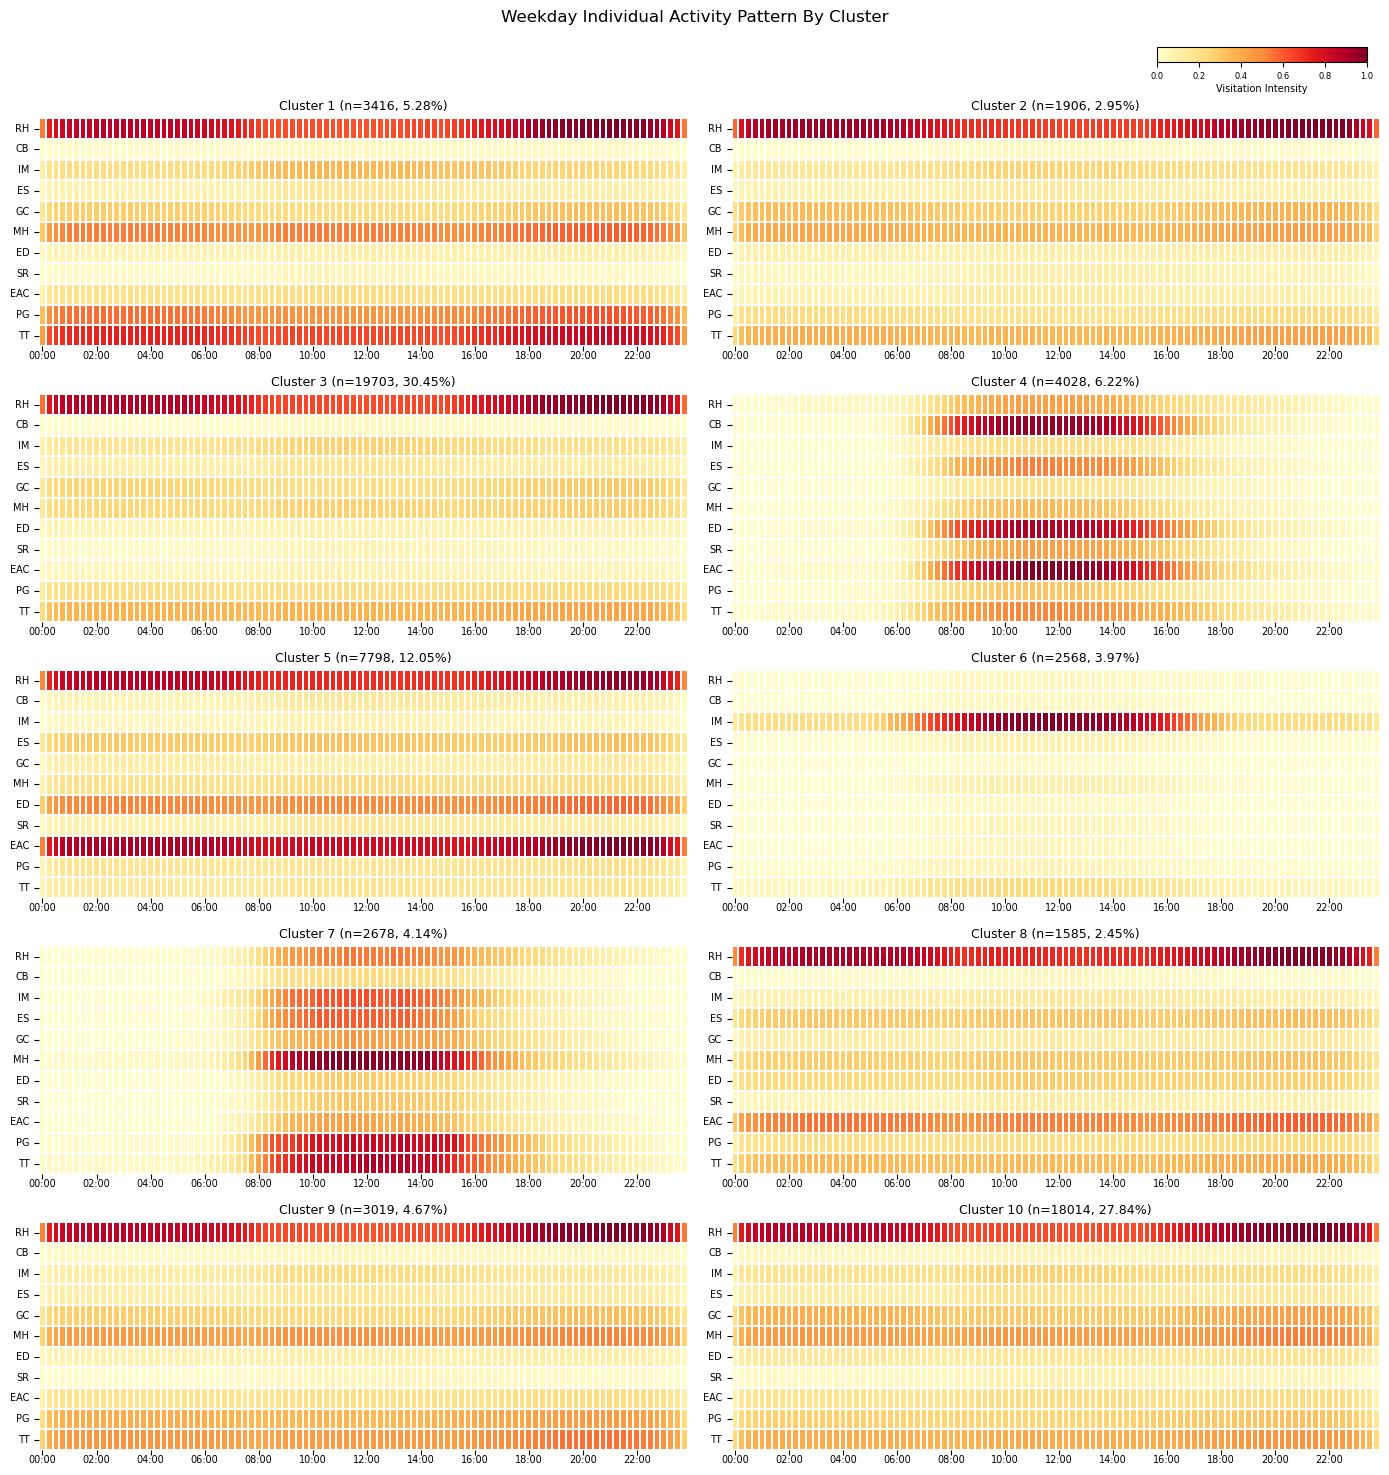

In [34]:
plot_cluster_grid(
    df_to_plot,
    title="Weekday Individual Activity Pattern By Cluster",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name='time_bucket',
    cluster_user_counts=weekday_cluster_user_counts,
    n_rows=5,
    n_cols=2,
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekday_activity_pattern_by_cluster_indi-sum-nonorm_cluster-mean-globalnorm.png'
)

In [ ]:
# Figure saving is handled inside plot_cluster_grid via analysis_fig_dir.
# Avoid calling plt.savefig here, because after plt.show() it may save an empty or stale figure.


Normalising by individual along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']
Normalising by cluster along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']


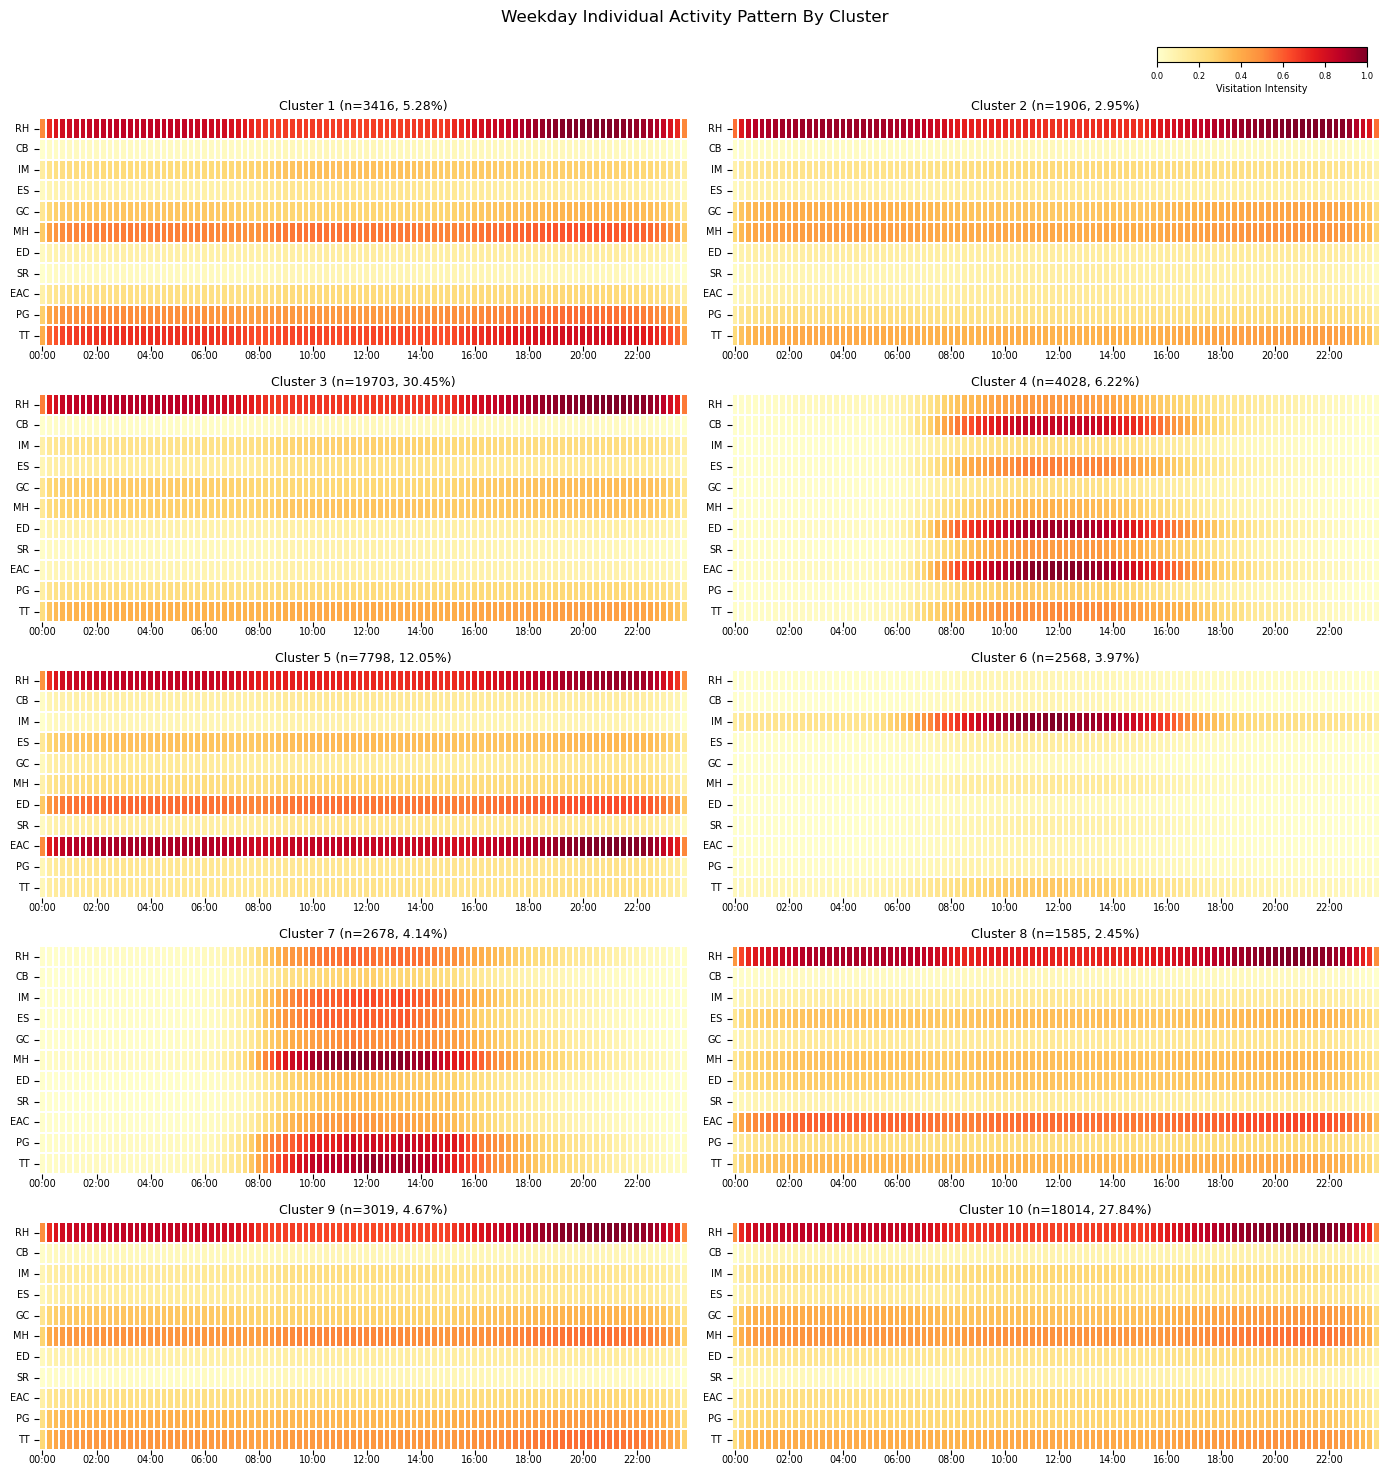

In [35]:
# indi-sum-globalnorm_cluster-mean-gnorm

weekday_indi_act_pattern_normed = min_max_normalise_act_pattern(
    weekday_indi_act_pattern,
    list_semantics_short,
    norm_by_col_name='user_id',
    normalise_by='individual',
    axis=2  # 2 means global normalisation per group
)

df_to_plot = weekday_indi_act_pattern_normed.groupby([cluster_id_col, 'time_bucket'])[list_semantics_short].mean().reset_index()
df_to_plot = min_max_normalise_act_pattern(
    df_to_plot,
    list_semantics_short,
    norm_by_col_name=cluster_id_col,
    normalise_by='cluster',
    axis=2
)

plot_cluster_grid(
    df_to_plot,
    title="Weekday Individual Activity Pattern By Cluster",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name='time_bucket',
    cluster_user_counts=weekday_cluster_user_counts,
    n_rows=5,
    n_cols=2,
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekday_activity_pattern_by_cluster_indi-sum-gnorm_cluster-mean-gnorm.png'
)

#### Weekend

In [36]:
tmp = df_exploded[df_exploded['is_weekend'] == True]
# Sum up the semantic distributions of all stays for each individual in each time bucket
tmp = tmp.groupby(['user_id', 'active_buckets'], as_index=False).agg({'sem_dist': 'sum'})

# Get all time buckets for each user, even if they don't have activity in some buckets (i.e., sem_dist is missing)
weekend_indi_act_pattern = pd.DataFrame({
    'user_id': np.repeat(df_clustering_res_weekend['user_id'].unique(), 96),  # Each user has 96 time buckets
    'time_bucket': list(range(96)) * df_clustering_res_weekend['user_id'].nunique()
})

weekend_indi_act_pattern = pd.merge(weekend_indi_act_pattern, tmp, left_on=['user_id', 'time_bucket'], right_on=['user_id', 'active_buckets'], how='left')
weekend_indi_act_pattern.drop(columns=['active_buckets'], inplace=True)
weekend_indi_act_pattern = pd.merge(weekend_indi_act_pattern, df_clustering_res_weekend[['user_id', cluster_id_col]], on='user_id', how='left')

# Separate outlier cluster
weekend_indi_act_pattern_outlier = weekend_indi_act_pattern[weekend_indi_act_pattern[cluster_id_col] == -1].copy()
weekend_indi_act_pattern = weekend_indi_act_pattern[weekend_indi_act_pattern[cluster_id_col] != -1].copy()
# 5,609,280 rows if remove outlier cluster.

# Fill the missing values in 'sem_dist' with a list of zeros (indicating no activity in any semantic category for that time bucket)
weekend_indi_act_pattern['sem_dist'] = weekend_indi_act_pattern['sem_dist'].apply(
    lambda x: x if isinstance(x, (list, np.ndarray)) else np.array([0] * len(list_semantics_short))
)
weekend_indi_act_pattern_outlier['sem_dist'] = weekend_indi_act_pattern_outlier['sem_dist'].apply(
    lambda x: x if isinstance(x, (list, np.ndarray)) else np.array([0] * len(list_semantics_short))
)

weekend_indi_act_pattern

,user_id,time_bucket,sem_dist,cluster_id
0,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",2
1,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",2
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",2
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",2
4,0000c7af-c002-4e39-ad0e-975c01dbe25e,4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",2
...,...,...,...,...
7976923,ffff8ebb-33d5-4851-a36d-12de4548ea2e,91,"[1.1903454, 0.055878624, 0.25798476, 0.0501594...",1
7976924,ffff8ebb-33d5-4851-a36d-12de4548ea2e,92,"[1.1903454, 0.055878624, 0.25798476, 0.0501594...",1
7976925,ffff8ebb-33d5-4851-a36d-12de4548ea2e,93,"[1.1903454, 0.055878624, 0.25798476, 0.0501594...",1
7976926,ffff8ebb-33d5-4851-a36d-12de4548ea2e,94,"[1.1903454, 0.055878624, 0.25798476, 0.0501594...",1


In [37]:
weekend_indi_act_pattern = explode_sem_dist_2_columns(weekend_indi_act_pattern, list_semantics_short, sem_dist_col='sem_dist')
weekend_indi_act_pattern_outlier = explode_sem_dist_2_columns(weekend_indi_act_pattern_outlier, list_semantics_short, sem_dist_col='sem_dist')

weekend_indi_act_pattern

,user_id,time_bucket,cluster_id,RH,CB,IM,ES,GC,MH,ED,SR,EAC,PG,TT
0,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,3,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0000c7af-c002-4e39-ad0e-975c01dbe25e,4,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7976923,ffff8ebb-33d5-4851-a36d-12de4548ea2e,91,1,1.190345,0.055879,0.257985,0.050159,0.117158,0.689090,0.049272,0.036104,0.061681,0.051812,0.440516
7976924,ffff8ebb-33d5-4851-a36d-12de4548ea2e,92,1,1.190345,0.055879,0.257985,0.050159,0.117158,0.689090,0.049272,0.036104,0.061681,0.051812,0.440516
7976925,ffff8ebb-33d5-4851-a36d-12de4548ea2e,93,1,1.190345,0.055879,0.257985,0.050159,0.117158,0.689090,0.049272,0.036104,0.061681,0.051812,0.440516
7976926,ffff8ebb-33d5-4851-a36d-12de4548ea2e,94,1,1.190345,0.055879,0.257985,0.050159,0.117158,0.689090,0.049272,0.036104,0.061681,0.051812,0.440516


Normalising by individual along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']
Normalising by cluster along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']


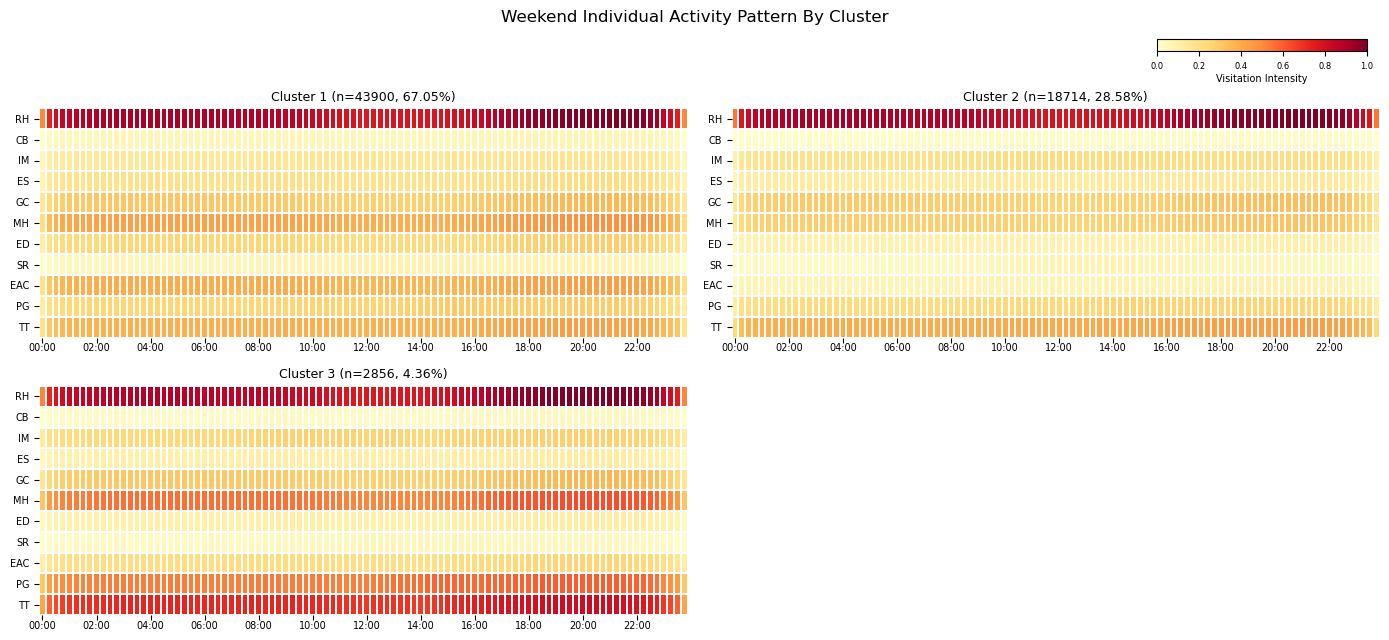

In [38]:
# indi-sum-globalnorm_cluster-mean-gnorm

weekend_indi_act_pattern_normed = min_max_normalise_act_pattern(
    weekend_indi_act_pattern,
    list_semantics_short,
    norm_by_col_name='user_id',
    normalise_by='individual',
    axis=2  # 2 means global normalisation per group
)

df_to_plot = weekend_indi_act_pattern_normed.groupby([cluster_id_col, 'time_bucket'])[list_semantics_short].mean().reset_index()
df_to_plot = min_max_normalise_act_pattern(
    df_to_plot,
    list_semantics_short,
    norm_by_col_name=cluster_id_col,
    normalise_by='cluster',
    axis=2
)

plot_cluster_grid(
    df_to_plot,
    title="Weekend Individual Activity Pattern By Cluster",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name='time_bucket',
    cluster_user_counts=weekend_cluster_user_counts,
    n_rows=4,
    n_cols=2,
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekend_activity_pattern_by_cluster_indi-sum-gnorm_cluster-mean-gnorm.png'
)

#### Residual Analysis

In [39]:
# We derive the mean indi pattern (take all Londoner's mean)
weekday_indi_act_pattern_all = pd.concat([
    weekday_indi_act_pattern,
    weekday_indi_act_pattern_outlier
], ignore_index=True).reset_index(drop=True)

print(f"Number of unique users in weekday_indi_act_pattern_all: {weekday_indi_act_pattern_all['user_id'].nunique()}")

weekday_indi_act_pattern_all

Number of unique users in weekday_indi_act_pattern_all: 104711


,user_id,time_bucket,cluster_id,RH,CB,IM,ES,GC,MH,ED,SR,EAC,PG,TT
0,000088cc-b646-409b-a026-69cd9d47b838,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,000088cc-b646-409b-a026-69cd9d47b838,1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,000088cc-b646-409b-a026-69cd9d47b838,2,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,000088cc-b646-409b-a026-69cd9d47b838,3,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,000088cc-b646-409b-a026-69cd9d47b838,4,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10052251,fffdfff3-7c45-43c0-a23e-8534c72a3a19,91,-1,1.629962,0.236671,0.141112,0.240065,0.299192,0.517207,1.415187,0.150409,0.346540,0.226863,0.796791
10052252,fffdfff3-7c45-43c0-a23e-8534c72a3a19,92,-1,1.394701,0.211134,0.083279,0.168081,0.287137,0.462083,1.378453,0.144511,0.249595,0.200661,0.420364
10052253,fffdfff3-7c45-43c0-a23e-8534c72a3a19,93,-1,1.104841,0.164735,0.076917,0.144057,0.218367,0.360343,1.043023,0.109858,0.211433,0.157046,0.409380
10052254,fffdfff3-7c45-43c0-a23e-8534c72a3a19,94,-1,1.104841,0.164735,0.076917,0.144057,0.218367,0.360343,1.043023,0.109858,0.211433,0.157046,0.409380


Normalising by individual along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']
Normalising by individual along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']
Normalising by cluster along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']
Normalising by cluster along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']


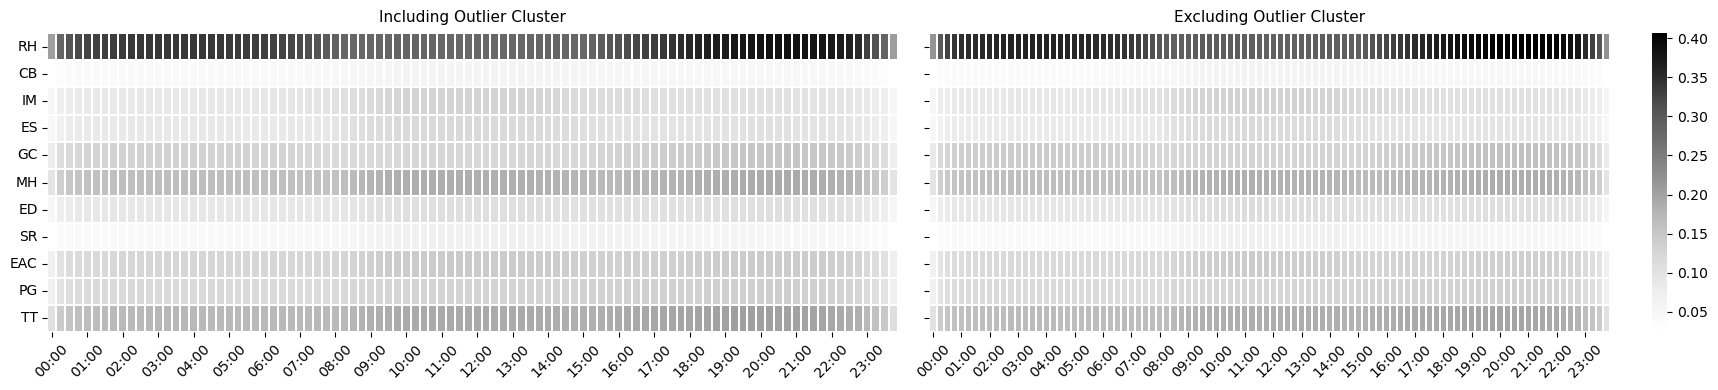

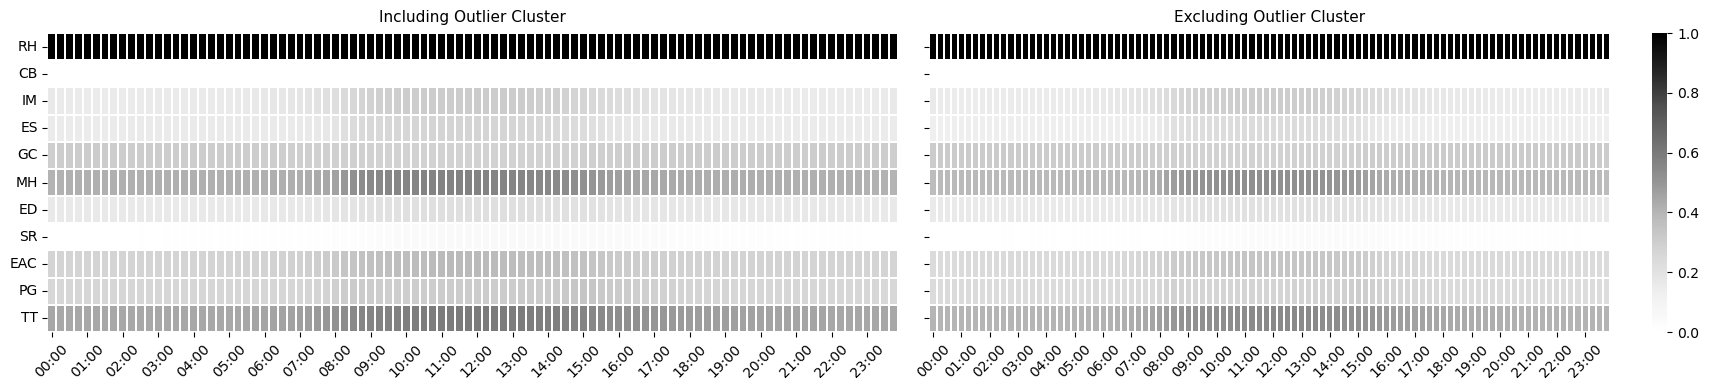

In [40]:
# Indi-sum-gnorm, then take the mean
weekday_indi_act_pattern_normed = min_max_normalise_act_pattern(
    weekday_indi_act_pattern,
    list_semantics_short,
    norm_by_col_name='user_id',
    normalise_by='individual',
    axis=2  # 2 means global normalisation per group
)

weekday_indi_act_pattern_all_normed = min_max_normalise_act_pattern(
    weekday_indi_act_pattern_all,
    list_semantics_short,
    norm_by_col_name='user_id',
    normalise_by='individual',
    axis=2  # 2 means global normalisation per group
)

act_pattern_baseline_all = weekday_indi_act_pattern_all_normed.groupby("time_bucket")[list_semantics_short].mean().reset_index()
act_pattern_baseline = weekday_indi_act_pattern_normed.groupby("time_bucket")[list_semantics_short].mean().reset_index()

act_pattern_baseline_all_normed = min_max_normalise_act_pattern(
    act_pattern_baseline_all,
    list_semantics_short,
    norm_by_col_name='time_bucket',
    normalise_by='cluster',
    axis=2
)
act_pattern_baseline_normed = min_max_normalise_act_pattern(
    act_pattern_baseline,
    list_semantics_short,
    norm_by_col_name='time_bucket',
    normalise_by='cluster',
    axis=2
)

def plot_baseline_heatmap_subplots(dfs, titles, list_semantics, time_bucket_col_name, cmap="Greys", if_save_fig=False, save_fig_path=None):
    heatmaps = [df.set_index(time_bucket_col_name)[list_semantics].T for df in dfs]
    vmin = min(heatmap.min().min() for heatmap in heatmaps)
    vmax = max(heatmap.max().max() for heatmap in heatmaps)

    fig, axes = plt.subplots(1, len(heatmaps), figsize=(18, 4), sharey=True)
    if len(heatmaps) == 1:
        axes = [axes]

    tick_positions = [i + 0.5 for i in range(0, 96, 4)]
    tick_labels = [f"{int(i/4):02d}:00" for i in range(0, 96, 4)]

    for idx, (ax, df_t, title) in enumerate(zip(axes, heatmaps, titles)):
        sns.heatmap(
            df_t,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            linewidths=0.01,
            linecolor='white',
            cbar=(idx == len(heatmaps) - 1),
        )
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45)
        ax.set_title(title, fontsize=11, pad=8)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()

    if if_save_fig and save_fig_path:
        plt.savefig(save_fig_path, bbox_inches='tight', dpi=400)
    plt.show()

plot_baseline_heatmap_subplots(
    dfs=[act_pattern_baseline_all.copy(), act_pattern_baseline.copy()],
    titles=[
        "Including Outlier Cluster",
        "Excluding Outlier Cluster",
    ],
    list_semantics=list_semantics_short,
    time_bucket_col_name='time_bucket',
    cmap="Greys",
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekday_baseline_activity_pattern_with_without_outlier_indi-sum-gnorm_mean.png',
)

plot_baseline_heatmap_subplots(
    dfs=[act_pattern_baseline_all_normed.copy(), act_pattern_baseline_normed.copy()],
    titles=[
        "Including Outlier Cluster",
        "Excluding Outlier Cluster",
    ],
    list_semantics=list_semantics_short,
    time_bucket_col_name='time_bucket',
    cmap="Greys",
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekday_baseline_activity_pattern_with_without_outlier_indi-sum-gnorm_mean-gnorm.png',
)

In [ ]:
act_pattern_baseline_all

In [43]:
# We subtract the baseline pattern from each cluster's mean pattern to see the relative difference compared to the overall average pattern. 
# This can help us identify which clusters have higher or lower activity in certain time buckets and semantics compared to the baseline.

df_to_plot = weekday_indi_act_pattern_normed.groupby([cluster_id_col, 'time_bucket'])[list_semantics_short].mean().reset_index()

df_to_plot_normed = min_max_normalise_act_pattern(
    df_to_plot,
    list_semantics_short,
    norm_by_col_name='time_bucket',
    normalise_by='cluster',
    axis=2
)

Normalising by cluster along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']


In [44]:
df_to_plot.describe()

,cluster_id,time_bucket,RH,CB,IM,ES,GC,MH,ED,SR,EAC,PG,TT
count,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000
mean,5.500000,47.500000,0.278191,0.041917,0.093884,0.084600,0.107086,0.149883,0.089034,0.048045,0.125516,0.110382,0.158397
std,2.873778,27.725754,0.173509,0.029662,0.057046,0.051686,0.070989,0.088039,0.071879,0.027002,0.113655,0.064682,0.087022
min,1.000000,0.000000,0.001618,0.000742,0.001018,0.000898,0.000928,0.001010,0.000828,0.000738,0.001293,0.001266,0.002475
25%,3.000000,23.750000,0.064663,0.027264,0.065032,0.052078,0.036036,0.063373,0.042809,0.030580,0.053149,0.050673,0.091242
50%,5.500000,47.500000,0.341324,0.035540,0.091993,0.080878,0.104564,0.162450,0.072158,0.046802,0.093975,0.116253,0.190797
75%,8.000000,71.250000,0.412565,0.047532,0.122153,0.111757,0.167552,0.231646,0.117843,0.069557,0.139910,0.147774,0.224985
max,10.000000,95.000000,0.527113,0.154665,0.341232,0.182829,0.238189,0.286840,0.289912,0.104221,0.437098,0.234503,0.315912


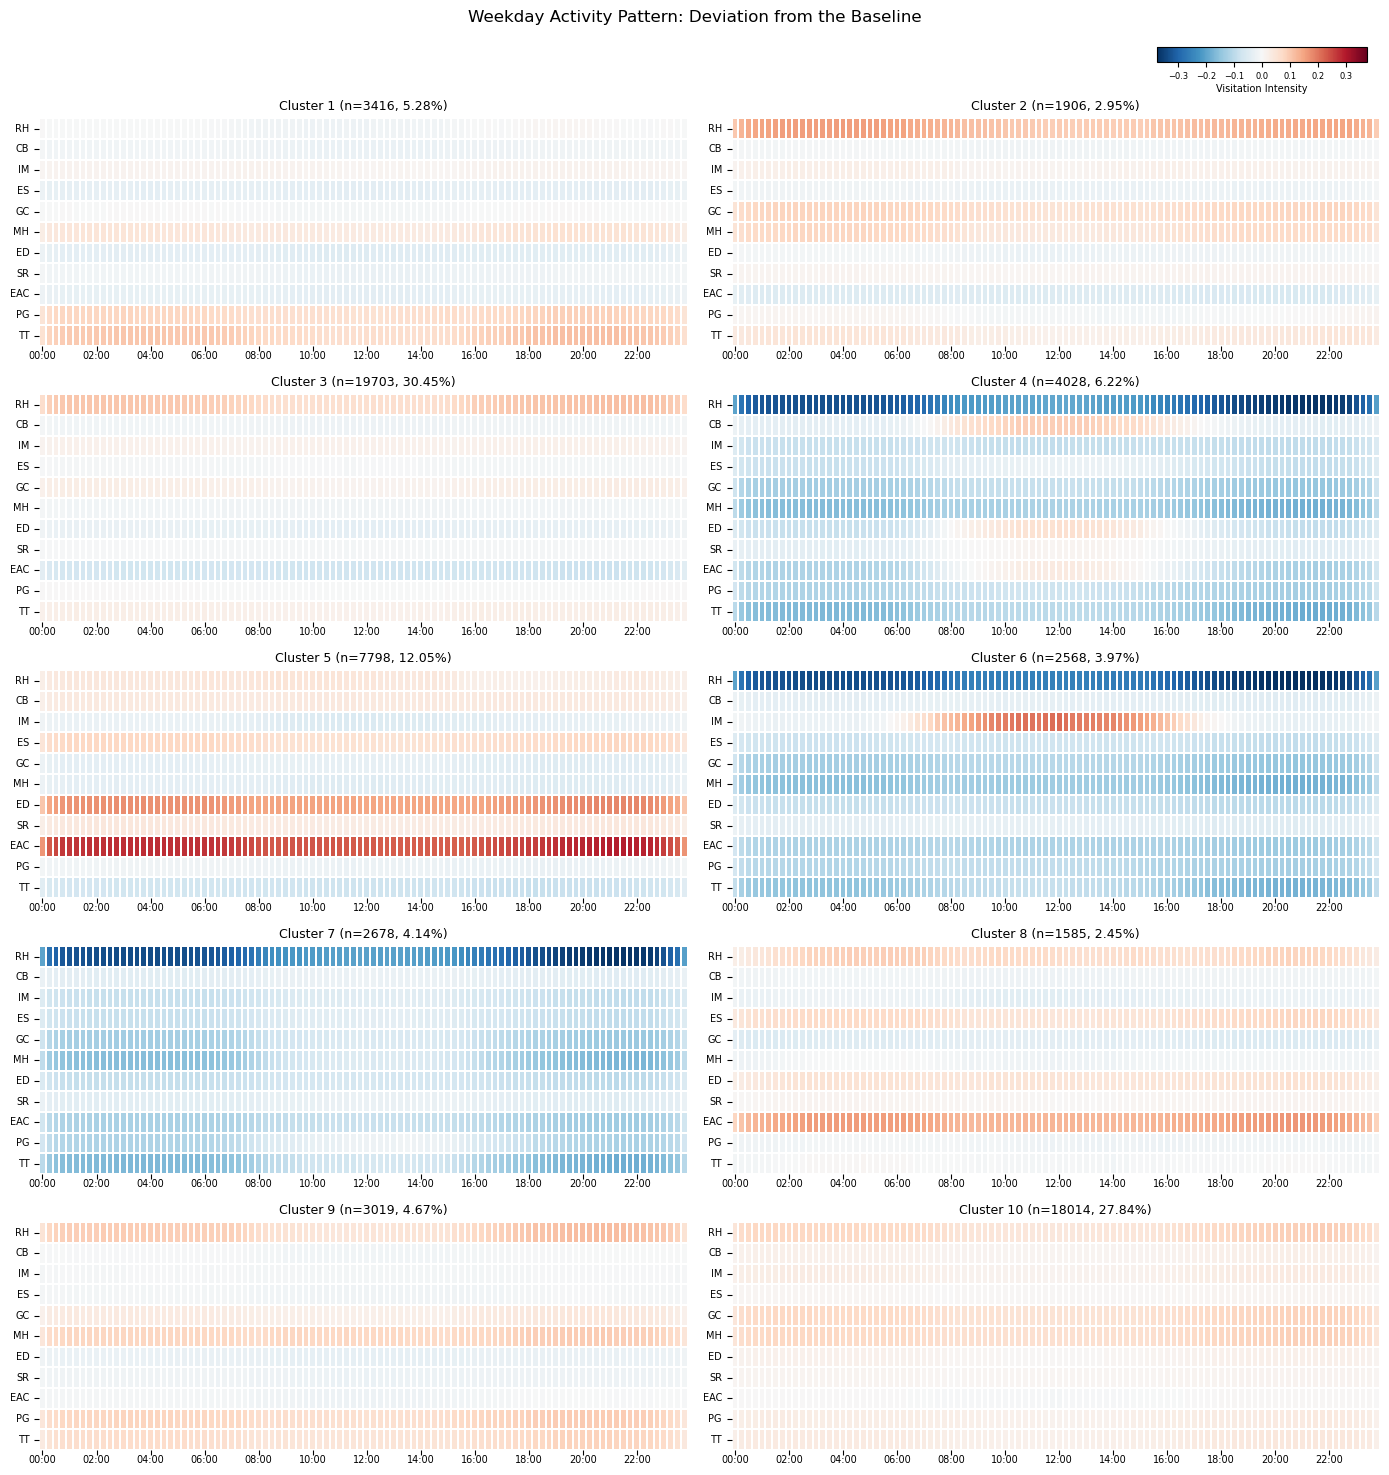

In [46]:
# Subtract the baseline pattern from each cluster's mean pattern
df_to_plot_subtracted = df_to_plot.copy()

def subtract_baseline(row, baseline):
    time_bucket = row['time_bucket']
    baseline_row = baseline[baseline['time_bucket'] == time_bucket]
    if not baseline_row.empty:
        return row[list_semantics_short] - baseline_row[list_semantics_short].values[0]
    else:
        return row[list_semantics_short]

# Subtract from baseline_all which includes the outlier cluster, because the cluster-level patterns we are plotting also include the outlier cluster.
df_to_plot_subtracted[list_semantics_short] = df_to_plot_subtracted.apply(lambda row: subtract_baseline(row, act_pattern_baseline_all), axis=1)

plot_cluster_grid(
    df_to_plot_subtracted,
    title="Weekday Activity Pattern: Deviation from the Baseline",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name='time_bucket',
    cluster_user_counts=weekday_cluster_user_counts,
    n_rows=5,
    n_cols=2,
    cmap="RdBu_r",  # Blue-White-Red diverging colour map to show positive and negative differences
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / 'weekday_cluster_activity_pattern_relative_to_baseline.png',
    is_residual=True
)

In [ ]:
df_to_plot_subtracted_cluster_3 = df_to_plot_subtracted[df_to_plot_subtracted[cluster_id_col] == 3].copy()

In [ ]:
df_to_plot_subtracted_cluster_3['ES'].describe()

#### Weekend Residual Analysis


In [47]:
# Derive the weekend mean individual pattern, including and excluding outlier users.
weekend_indi_act_pattern_all = pd.concat([
    weekend_indi_act_pattern,
    weekend_indi_act_pattern_outlier,
], ignore_index=True).reset_index(drop=True)

print("Number of unique users in weekend_indi_act_pattern_all: {}".format(weekend_indi_act_pattern_all["user_id"].nunique()))

weekend_indi_act_pattern_all


Number of unique users in weekend_indi_act_pattern_all: 83093


,user_id,time_bucket,cluster_id,RH,CB,IM,ES,GC,MH,ED,SR,EAC,PG,TT
0,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,3,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0000c7af-c002-4e39-ad0e-975c01dbe25e,4,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7976923,fffa0e3a-1045-4557-ad04-00e009251585,91,-1,0.325908,0.647334,0.182745,0.031871,0.345634,0.338053,1.028784,0.666375,0.333930,0.031486,0.067881
7976924,fffa0e3a-1045-4557-ad04-00e009251585,92,-1,0.325908,0.647334,0.182745,0.031871,0.345634,0.338053,1.028784,0.666375,0.333930,0.031486,0.067881
7976925,fffa0e3a-1045-4557-ad04-00e009251585,93,-1,0.244431,0.485500,0.137058,0.023903,0.259225,0.253540,0.771588,0.499781,0.250447,0.023614,0.050911
7976926,fffa0e3a-1045-4557-ad04-00e009251585,94,-1,0.244431,0.485500,0.137058,0.023903,0.259225,0.253540,0.771588,0.499781,0.250447,0.023614,0.050911


Normalising by individual along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']
Normalising by individual along axis 2 for columns: ['RH', 'CB', 'IM', 'ES', 'GC', 'MH', 'ED', 'SR', 'EAC', 'PG', 'TT']


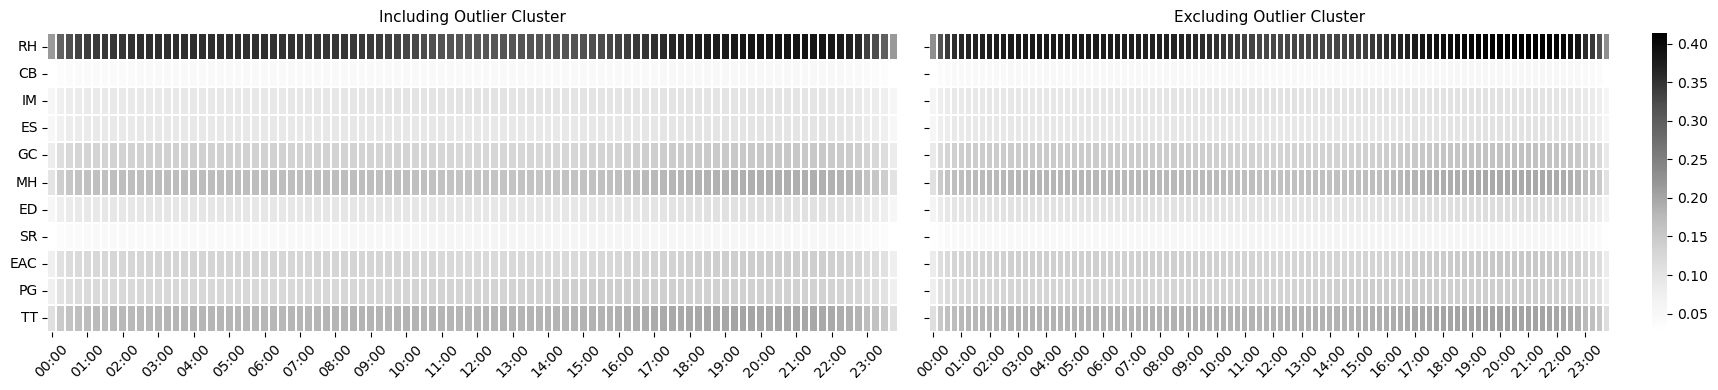

In [48]:
# Indi-sum-gnorm, then take the mean.
weekend_indi_act_pattern_normed_residual = min_max_normalise_act_pattern(
    weekend_indi_act_pattern,
    list_semantics_short,
    norm_by_col_name="user_id",
    normalise_by="individual",
    axis=2,
)

weekend_indi_act_pattern_all_normed = min_max_normalise_act_pattern(
    weekend_indi_act_pattern_all,
    list_semantics_short,
    norm_by_col_name="user_id",
    normalise_by="individual",
    axis=2,
)

weekend_act_pattern_baseline_all = weekend_indi_act_pattern_all_normed.groupby("time_bucket")[list_semantics_short].mean().reset_index()
weekend_act_pattern_baseline = weekend_indi_act_pattern_normed_residual.groupby("time_bucket")[list_semantics_short].mean().reset_index()

plot_baseline_heatmap_subplots(
    dfs=[weekend_act_pattern_baseline_all.copy(), weekend_act_pattern_baseline.copy()],
    titles=[
        "Including Outlier Cluster",
        "Excluding Outlier Cluster",
    ],
    list_semantics=list_semantics_short,
    time_bucket_col_name="time_bucket",
    cmap="Greys",
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / "weekend_baseline_activity_pattern_with_without_outlier_indi-sum-gnorm_mean.png",
)


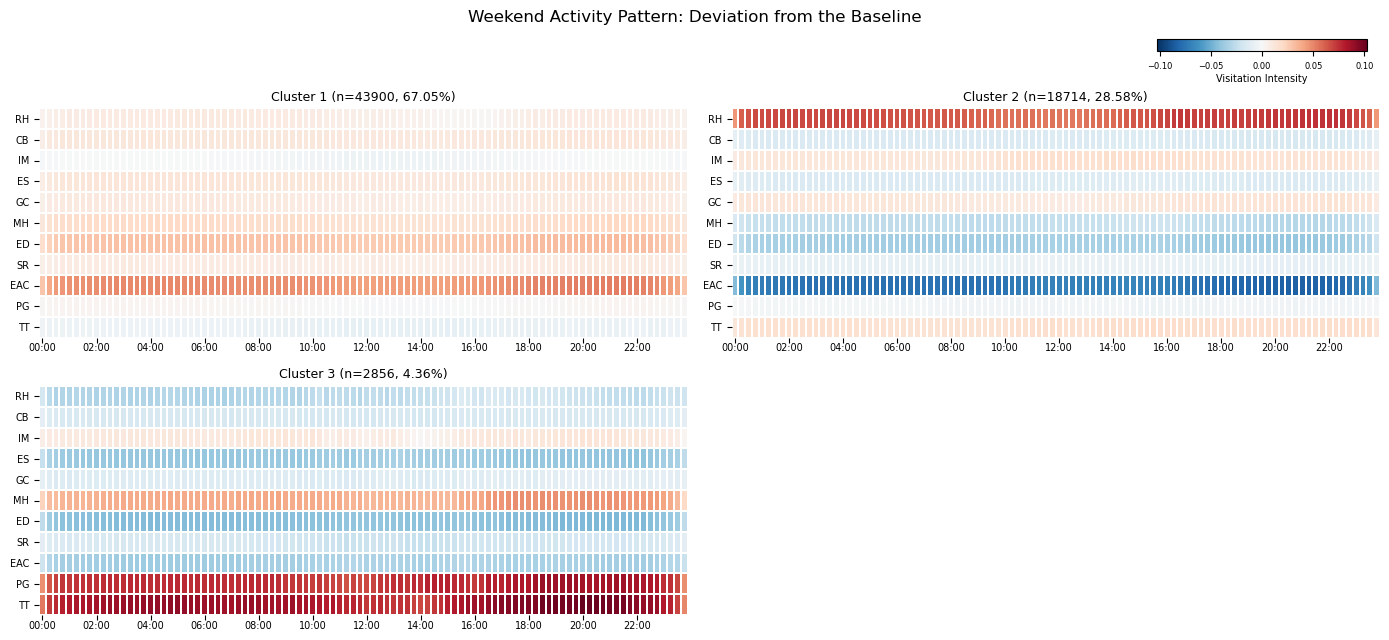

In [49]:
# Subtract the weekend baseline pattern from each weekend cluster mean pattern.
weekend_df_to_plot = weekend_indi_act_pattern_normed_residual.groupby(
    [cluster_id_col, "time_bucket"]
)[list_semantics_short].mean().reset_index()

weekend_df_to_plot_subtracted = weekend_df_to_plot.copy()
weekend_df_to_plot_subtracted[list_semantics_short] = weekend_df_to_plot_subtracted.apply(
    lambda row: subtract_baseline(row, weekend_act_pattern_baseline_all),
    axis=1,
)

plot_cluster_grid(
    weekend_df_to_plot_subtracted,
    title="Weekend Activity Pattern: Deviation from the Baseline",
    cluster_col_name=cluster_id_col,
    list_semantics=list_semantics_short,
    time_bucket_col_name="time_bucket",
    cluster_user_counts=weekend_cluster_user_counts,
    n_rows=4,
    n_cols=2,
    cmap="RdBu_r",
    if_save_fig=True,
    save_fig_path=analysis_fig_dir / "weekend_cluster_activity_pattern_relative_to_baseline.png",
    is_residual=True
)


In [ ]:
inspect_tmp = weekday_indi_act_pattern_normed[weekday_indi_act_pattern_normed['user_id'] == weekday_indi_act_pattern_normed.loc[0, "user_id"]]
inspect_tmp

## 3. Persona Profiling

This section enriches the ACE clusters with home-location geography and LSOA-level census profiles. Outputs are written to the selected experiment directory under `analysis_data/personas` and `analysis_figs/personas`.


In [50]:
persona_data_dir = analysis_data_dir / "personas"
persona_fig_dir = analysis_fig_dir / "personas"
persona_data_dir.mkdir(parents=True, exist_ok=True)
persona_fig_dir.mkdir(parents=True, exist_ok=True)

boundary_root = Path("~/data/boundary").expanduser()
census_root = Path("~/data/census21").expanduser()

print(f"Persona data will be saved to: {persona_data_dir}")
print(f"Persona figures will be saved to: {persona_fig_dir}")


Persona data will be saved to: pretrained_ace/london_aether/experiments/20260525_180711_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1/analysis_data/personas
Persona figures will be saved to: pretrained_ace/london_aether/experiments/20260525_180711_mask-all_emb-prompt_prompt-1_maskp0.2_minmask0_sw1_mw1/analysis_figs/personas


### 3.1. Boundary and LSOA Data


In [51]:
london_boundary = gpd.read_file(boundary_root / "london" / "london.shp")
london_bbox = london_boundary.total_bounds
gdf_london_bbox = gpd.GeoDataFrame(geometry=[box(*london_bbox)], crs=london_boundary.crs)

england_lsoas = gpd.read_file(boundary_root / "england" / "england_lsoa_2021.shp")
if england_lsoas.crs != london_boundary.crs:
    england_lsoas = england_lsoas.to_crs(london_boundary.crs)

london_lsoas = england_lsoas[england_lsoas.intersects(gdf_london_bbox.geometry.iloc[0])].copy()
london_lsoas = london_lsoas.drop(columns=[col for col in ["label", "name"] if col in london_lsoas.columns])
if london_lsoas.crs != proj_crs:
    london_lsoas = london_lsoas.to_crs(proj_crs)

london_lsoas_id = london_lsoas["lsoa21cd"].tolist()
print(f"Number of LSOAs in London bbox: {len(london_lsoas_id)}")
london_lsoas.head()


Number of LSOAs in London bbox: 5783


,lsoa21cd,lsoa21nm,geometry
3,E01004171,Sutton 010A,"POLYGON ((529467.299 165179.478, 529470.063 16..."
12,E01034606,Hillingdon 016G,"POLYGON ((505620.473 183176.363, 505622.878 18..."
16,E01030373,Elmbridge 012C,"POLYGON ((508793.002 166442.914, 508794.094 16..."
18,E01004000,Southwark 026A,"POLYGON ((535339.169 176529.5, 535364.316 1765..."
27,E01001070,Croydon 040B,"POLYGON ((531420.995 159670.607, 531422.235 15..."


### 3.2. Census Distributions


In [52]:
column_mapping = {
    "Lower layer Super Output Areas Code": "lsoa21cd",
    "Lower layer Super Output Areas": "lsoa21nm",
}

def read_london_lsoa_census(filename):
    df = pd.read_csv(census_root / filename).rename(columns=column_mapping)
    return df[df["lsoa21cd"].isin(london_lsoas_id)].copy()

raw_census = {
    "age": read_london_lsoa_census("england_lsoa_age.csv"),
    "occupation": read_london_lsoa_census("england_lsoa_occupation_current.csv"),
    "sec": read_london_lsoa_census("england_lsoa_ns-sec.csv"),
    "education": read_london_lsoa_census("england_lsoa_edu.csv"),
    "commute": read_london_lsoa_census("england_lsoa_distance2work.csv"),
}

census_specs = {
    "age": {
        "code_col": "Age (6 categories) Code",
        "label_col": "Age (6 categories)",
        "prefix": "age",
    },
    "occupation": {
        "code_col": "Occupation (current) (10 categories) Code",
        "label_col": "Occupation (current) (10 categories)",
        "prefix": "occ",
    },
    "sec": {
        "code_col": "National Statistics Socio-economic Classification (NS-SeC) (10 categories) Code",
        "label_col": "National Statistics Socio-economic Classification (NS-SeC) (10 categories)",
        "prefix": "nssec",
    },
    "education": {
        "code_col": "Highest level of qualification (7 categories) Code",
        "label_col": "Highest level of qualification (7 categories)",
        "prefix": "edu",
    },
    "commute": {
        "code_col": "Distance travelled to work (8 categories) Code",
        "label_col": "Distance travelled to work (8 categories)",
        "prefix": "comm",
    },
}

def make_lsoa_distribution(df, demo_type, spec):
    code_col = spec["code_col"]
    label_col = spec["label_col"]
    prefix = spec["prefix"]
    long_df = df.rename(columns={code_col: "code", label_col: "label", "Observation": "count"}).copy()
    long_df["code"] = pd.to_numeric(long_df["code"], errors="coerce")
    long_df = long_df[long_df["code"].notna() & (long_df["code"] != -8)].copy()
    long_df["code"] = long_df["code"].astype(int)

    mapping = long_df[["code", "label"]].drop_duplicates().sort_values("code")
    mapping.to_csv(persona_data_dir / f"mapping_{demo_type}_code_label.csv", index=False)

    codes = sorted(long_df["code"].unique())
    out_cols = [f"{prefix}_{code}" for code in codes]
    wide = long_df.pivot_table(
        index="lsoa21cd",
        columns="code",
        values="count",
        aggfunc="sum",
        fill_value=0,
    )
    wide = wide.reindex(columns=codes, fill_value=0)
    wide.columns = out_cols
    row_sums = wide.sum(axis=1).replace(0, np.nan)
    wide = wide.div(row_sums, axis=0).fillna(0).reset_index()
    wide.columns.name = None
    return wide[["lsoa21cd"] + out_cols]

london_lsoa_demo = {
    demo_type: make_lsoa_distribution(raw_census[demo_type], demo_type, spec)
    for demo_type, spec in census_specs.items()
}

for demo_type, df_demo in london_lsoa_demo.items():
    df_demo.to_csv(persona_data_dir / f"london_lsoa_{demo_type}_dist.csv", index=False)
    print(demo_type, df_demo.shape)


age (5783, 7)
occupation (5783, 10)
sec (5783, 10)
education (5783, 7)
commute (5783, 8)


### 3.3. Home Locations by Cluster


In [53]:
df_clustering_res_weekday['cluster_id']

0          1
1         -1
2         10
3          9
4         -1
          ..
104706     9
104707     1
104708     3
104709     1
104710     2
Name: cluster_id, Length: 104711, dtype: int64

In [54]:
sigplaces_path = Path("sigplaces_and_home") / f"{city}_{str_study_period}_sigplaces_with_home.csv.gz"
df_sigplaces_with_home = pd.read_csv(sigplaces_path)

df_home = df_sigplaces_with_home[df_sigplaces_with_home["is_home"] == True].copy()
df_home = df_home.rename(columns={"cluster_x": "x", "cluster_y": "y"})
df_home = df_home.drop_duplicates(subset=["user_id", "significant_place"])

required_home_cols = {"user_id", "x", "y"}
missing_home_cols = required_home_cols - set(df_home.columns)
if missing_home_cols:
    raise KeyError(f"Missing expected home-location columns: {sorted(missing_home_cols)}")

df_home_with_user = pd.merge(
    df_home,
    df_clustering_res_weekday[["user_id", cluster_id_col]],
    on="user_id",
    how="inner",
)

print(f"Home locations with cluster labels: {len(df_home_with_user):,}")
df_home_with_user.head()


Home locations with cluster labels: 104,711


,user_id,significant_place,nighttime_length,total_time_s,x,y,is_home,cluster_id
0,000088cc-b646-409b-a026-69cd9d47b838,0,43200,95333,530161.650419,159894.898575,True,1
1,000135bd-bf0b-4880-af99-1791ce98dddf,0,122407,335275,521030.394811,168403.307828,True,-1
2,00016f95-edc9-4642-a6e6-70ce63b66346,0,416215,1076484,510222.828201,176659.702961,True,10
3,0001dfff-15bc-404b-a5f2-a1ec0b458766,0,358460,686739,525498.337102,162815.077297,True,9
4,00026b53-cb9f-4b07-aeb4-8e2aced6bb15,0,60732,136037,517868.857748,174175.896992,True,-1


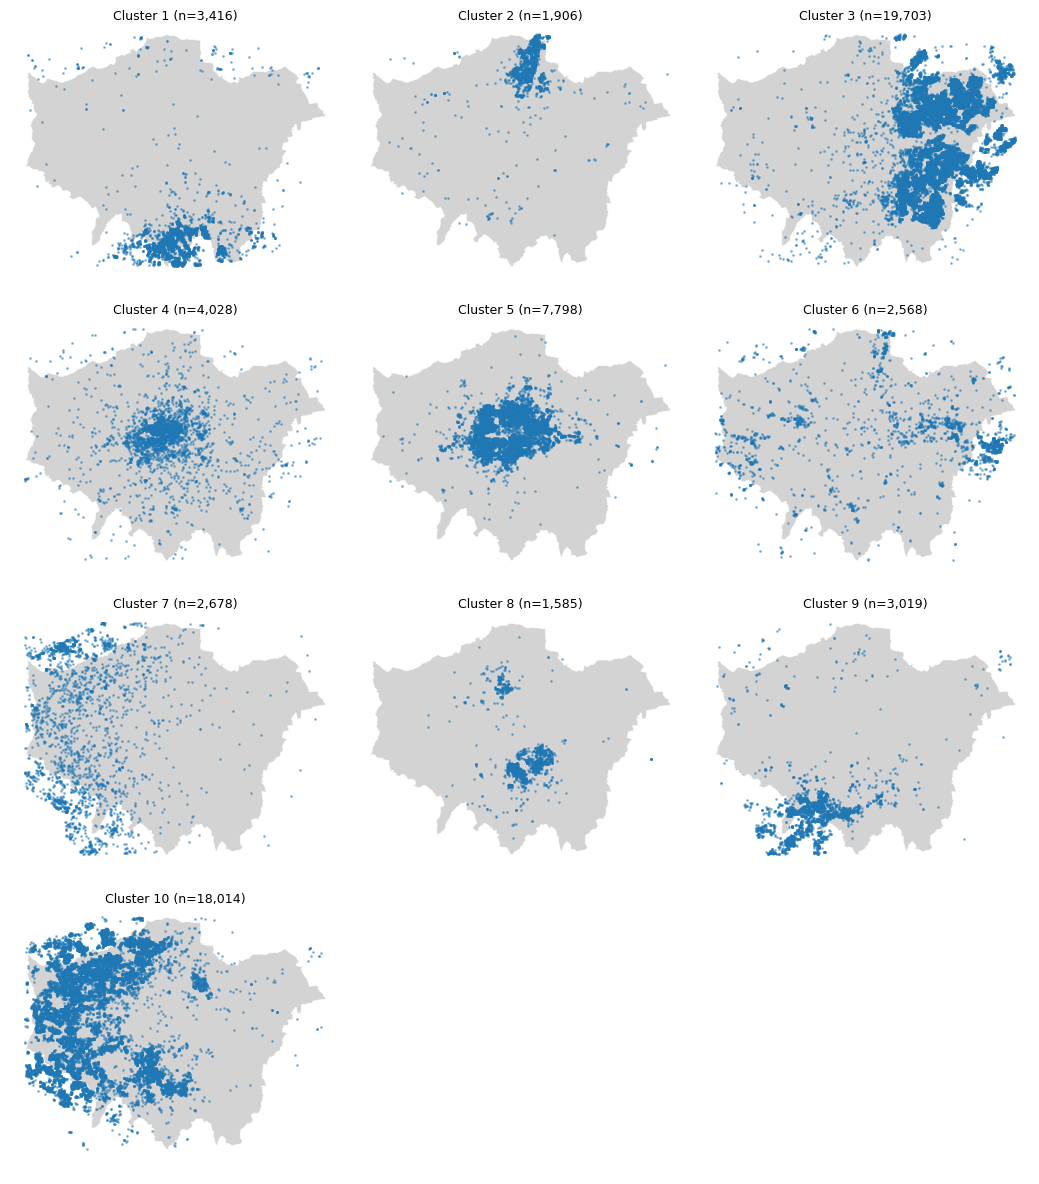

In [55]:
valid_clusters = sorted(c for c in df_home_with_user[cluster_id_col].dropna().unique() if c != -1)
n_cols = 3
n_rows = int(np.ceil(len(valid_clusters) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows))
axes = np.atleast_1d(axes).ravel()

boundary_plot = london_boundary.to_crs(proj_crs) if london_boundary.crs != proj_crs else london_boundary
for ax, cluster_id in zip(axes, valid_clusters):
    cluster_i = df_home_with_user[df_home_with_user[cluster_id_col] == cluster_id]
    boundary_plot.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.4)
    ax.scatter(cluster_i["x"], cluster_i["y"], s=1, alpha=0.45)
    ax.set_title(f"Cluster {cluster_id} (n={len(cluster_i):,})", fontsize=9, pad=0)
    ax.set_axis_off()

for ax in axes[len(valid_clusters):]:
    ax.set_axis_off()

# fig.suptitle("Home Location Distribution by ACE Cluster", fontsize=14)
plt.tight_layout()
fig.savefig(persona_fig_dir / "home_locations_by_cluster.png", dpi=400, bbox_inches="tight")
plt.show()


In [56]:
gdf_home = gpd.GeoDataFrame(
    df_home[["user_id", "x", "y"]].copy(),
    geometry=gpd.points_from_xy(df_home["x"], df_home["y"]),
    crs=proj_crs,
)

gdf_home_with_lsoa = gpd.sjoin(gdf_home, london_lsoas, how="left", predicate="within").drop(columns=["index_right"])
print(f"Number of users without matched LSOA: {gdf_home_with_lsoa['lsoa21cd'].isna().sum():,}")

gdf_home_with_lsoa_clst = pd.merge(
    gdf_home_with_lsoa,
    df_clustering_res_weekday[["user_id", cluster_id_col]],
    on="user_id",
    how="inner",
)

# Keep the noise cluster (-1) in demographic summaries so it can be compared with valid clusters.
gdf_home_with_lsoa_clst = gdf_home_with_lsoa_clst.copy()

gdf_home_with_lsoa_clst.to_file(persona_data_dir / "home_lsoa_with_clusters.geojson", driver="GeoJSON")
gdf_home_with_lsoa_clst.head()


Number of users without matched LSOA: 0


,user_id,x,y,geometry,lsoa21cd,lsoa21nm,cluster_id
0,000088cc-b646-409b-a026-69cd9d47b838,530161.650419,159894.898575,POINT (530161.65 159894.899),E01001023,Croydon 041C,1
1,000135bd-bf0b-4880-af99-1791ce98dddf,521030.394811,168403.307828,POINT (521030.395 168403.308),E01002930,Kingston upon Thames 007B,-1
2,00016f95-edc9-4642-a6e6-70ce63b66346,510222.828201,176659.702961,POINT (510222.828 176659.703),E01002584,Hounslow 013B,10
3,0001dfff-15bc-404b-a5f2-a1ec0b458766,525498.337102,162815.077297,POINT (525498.337 162815.077),E01004093,Sutton 025A,9
4,00026b53-cb9f-4b07-aeb4-8e2aced6bb15,517868.857748,174175.896992,POINT (517868.858 174175.897),E01003892,Richmond upon Thames 009A,-1


### 3.4. Demographic Profiles and Persona Evidence


In [57]:
def get_cluster_demo_dist(df_demo_dist, df_home_with_lsoa_clst, cluster_col):
    demo_cols = [col for col in df_demo_dist.columns if col != "lsoa21cd"]
    df = pd.merge(df_home_with_lsoa_clst[["user_id", "lsoa21cd", cluster_col]], df_demo_dist, on="lsoa21cd", how="left")
    cluster_dist = df.groupby(cluster_col)[demo_cols].mean().reset_index()
    row_sums = cluster_dist[demo_cols].sum(axis=1).replace(0, np.nan)
    cluster_dist[demo_cols] = cluster_dist[demo_cols].div(row_sums, axis=0).fillna(0)

    baseline_cluster_id = int(cluster_dist[cluster_col].max()) + 1
    overall_dist = df_demo_dist[demo_cols].mean().to_frame().T
    overall_dist[cluster_col] = baseline_cluster_id
    cluster_dist = pd.concat([cluster_dist, overall_dist], ignore_index=True)
    return cluster_dist, baseline_cluster_id

cluster_demo_dists = {}
baseline_ids = {}
for demo_type, df_demo_dist in london_lsoa_demo.items():
    clst_demo_dist, baseline_cluster_id = get_cluster_demo_dist(
        df_demo_dist,
        gdf_home_with_lsoa_clst,
        cluster_id_col,
    )
    cluster_demo_dists[demo_type] = clst_demo_dist
    baseline_ids[demo_type] = baseline_cluster_id
    clst_demo_dist.to_csv(persona_data_dir / f"cluster_{demo_type}_dist.csv", index=False)

cluster_demo_dists["age"].head()


,cluster_id,age_1,age_2,age_3,age_4,age_5,age_6
0,-1,0.194406,0.102926,0.162742,0.227058,0.178158,0.134710
1,1,0.195726,0.090397,0.111599,0.203224,0.204045,0.195010
2,2,0.223904,0.114616,0.145482,0.216767,0.181037,0.118194
3,3,0.212491,0.102408,0.139640,0.218157,0.181152,0.146151
4,4,0.129403,0.162558,0.245158,0.210234,0.153927,0.098719


In [58]:
residual_tables = {}
index_score_tables = {}
for demo_type, clst_demo_dist in cluster_demo_dists.items():
    baseline_cluster_id = baseline_ids[demo_type]
    demo_cols = [col for col in clst_demo_dist.columns if col != cluster_id_col]
    overall_dist = clst_demo_dist[clst_demo_dist[cluster_id_col] == baseline_cluster_id]

    residual_df = clst_demo_dist[[cluster_id_col]].copy()
    index_df = clst_demo_dist[[cluster_id_col]].copy()
    for col in demo_cols:
        baseline_value = overall_dist[col].values[0]
        residual_df[col] = clst_demo_dist[col] - baseline_value
        index_df[col] = np.where(baseline_value == 0, np.nan, (clst_demo_dist[col] / baseline_value) * 100)

    residual_df = residual_df[residual_df[cluster_id_col] != baseline_cluster_id].copy()
    index_df = index_df[index_df[cluster_id_col] != baseline_cluster_id].copy()

    residual_tables[demo_type] = residual_df
    index_score_tables[demo_type] = index_df
    residual_df.to_csv(persona_data_dir / f"cluster_{demo_type}_residuals.csv", index=False)
    index_df.to_csv(persona_data_dir / f"cluster_{demo_type}_index_scores.csv", index=False)

index_score_tables["age"].head()


,cluster_id,age_1,age_2,age_3,age_4,age_5,age_6
0,-1,101.112628,96.030646,94.161273,101.137648,102.247817,104.447174
1,1,101.799137,84.340940,64.570100,90.521069,117.104876,151.200703
2,2,116.454777,106.938039,84.174565,96.553531,103.900274,91.641738
3,3,110.518922,95.547708,80.794747,97.172972,103.966153,113.318001
4,4,67.304061,151.668075,141.846642,93.643709,88.341230,76.541925


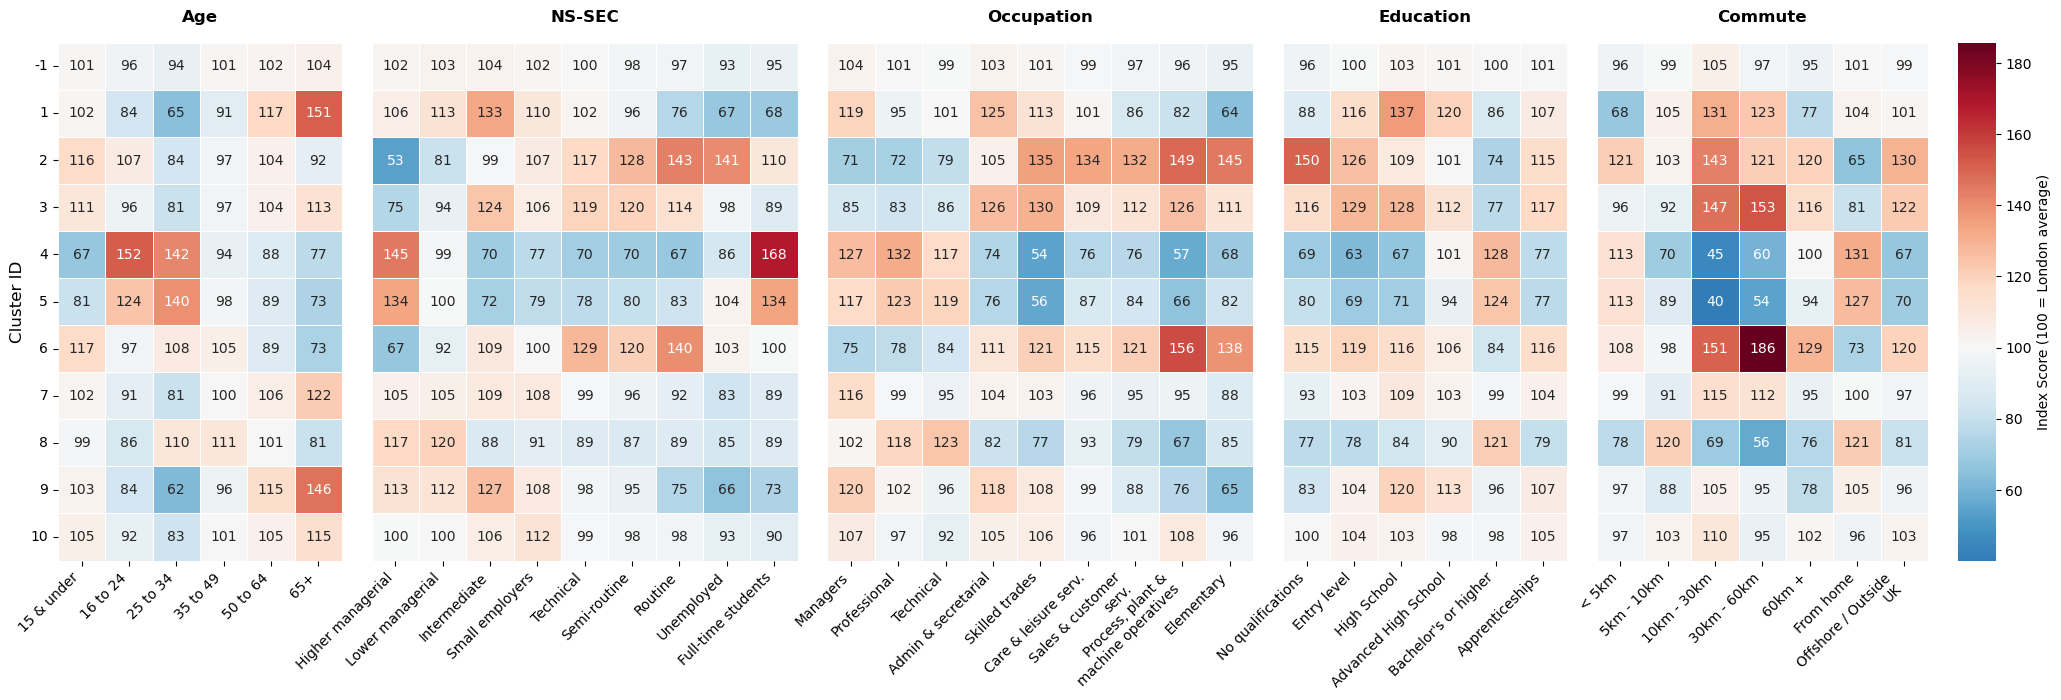

In [61]:
label_mapping = {
    "age_1": "15 & under",
    "age_2": "16 to 24",
    "age_3": "25 to 34",
    "age_4": "35 to 49",
    "age_5": "50 to 64",
    "age_6": "65+",
    "nssec_1": "Higher managerial",
    "nssec_2": "Lower managerial",
    "nssec_3": "Intermediate",
    "nssec_4": "Small employers",
    "nssec_5": "Technical",
    "nssec_6": "Semi-routine",
    "nssec_7": "Routine",
    "nssec_8": "Unemployed",
    "nssec_9": "Full-time students",
    "occ_1": "Managers",
    "occ_2": "Professional",
    "occ_3": "Technical",
    "occ_4": "Admin & secretarial",
    "occ_5": "Skilled trades",
    "occ_6": "Care & leisure serv.",
    "occ_7": "Sales & customer serv.",
    "occ_8": "Process, plant & machine operatives",
    "occ_9": "Elementary",
    "edu_0": "No qualifications",
    "edu_1": "Entry level",
    "edu_2": "High School",
    "edu_3": "Advanced High School",
    "edu_4": "Bachelor's or higher",
    "edu_5": "Apprenticeships",
    "comm_1": "< 5km",
    "comm_2": "5km - 10km",
    "comm_3": "10km - 30km",
    "comm_4": "30km - 60km",
    "comm_5": "60km +",
    "comm_6": "From home",
    "comm_7": "Offshore / Outside UK",
}

demo_types = ["age", "sec", "occupation", "education", "commute"]

cluster_ids = sorted(
    set().union(*[set(index_score_tables[demo_type][cluster_id_col]) for demo_type in demo_types])
)
cluster_order = ([-1] if -1 in cluster_ids else []) + [cluster_id for cluster_id in cluster_ids if cluster_id != -1]

heatmap_data_dict = {
    demo_type: index_score_tables[demo_type].set_index(cluster_id_col).reindex(cluster_order)
    for demo_type in demo_types
}

all_values = pd.concat([df.stack() for df in heatmap_data_dict.values()]).dropna()
vmin = min(all_values.min(), 100)
vmax = max(all_values.max(), 100)
widths = [max(len(heatmap_data_dict[demo_type].columns), 1) for demo_type in demo_types] + [0.8]
plot_titles = {
    "age": "Age",
    "sec": "NS-SEC",
    "occupation": "Occupation",
    "education": "Education",
    "commute": "Commute",
}

fig, axes = plt.subplots(
    1,
    len(demo_types) + 1,
    figsize=(25, 7),
    gridspec_kw={"wspace": 0.1, "width_ratios": widths},
)

for i, demo_type in enumerate(demo_types):
    ax = axes[i]
    data = heatmap_data_dict[demo_type]
    draw_cbar = i == len(demo_types) - 1
    sns.heatmap(
        data,
        cmap="RdBu_r",
        center=100,
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt=".0f",
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        cbar=draw_cbar,
        cbar_ax=axes[-1] if draw_cbar else None,
        cbar_kws={"label": "Index Score (100 = London average)"} if draw_cbar else None,
    )
    ax.set_title(plot_titles[demo_type], pad=15, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    new_labels = [label_mapping.get(tick.get_text(), tick.get_text()) for tick in ax.get_xticklabels()]
    wrapped_labels = [textwrap.fill(label, width=20) for label in new_labels]
    ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")
    if i == 0:
        ytick_labels = ["-1" if cluster_id == -1 else str(cluster_id) for cluster_id in data.index]
        ax.set_yticklabels(ytick_labels, rotation=0)
        ax.set_ylabel("Cluster ID", fontsize=12)
    else:
        ax.set_ylabel("")
        ax.set_yticks([])

# fig.suptitle("Demographic Index Scores by ACE Cluster (Relative to London Average)", fontsize=16)
plt.tight_layout()
fig.subplots_adjust(top=0.85)
fig.savefig(persona_fig_dir / "demographic_index_scores_by_cluster.png", dpi=400, bbox_inches="tight")
fig.savefig(persona_fig_dir / "demographic_index_scores_by_cluster.pdf", bbox_inches="tight")
plt.show()


In [ ]:
persona_evidence = []
for demo_type, index_df in index_score_tables.items():
    demo_cols = [col for col in index_df.columns if col != cluster_id_col]
    for _, row in index_df.iterrows():
        cluster_id = row[cluster_id_col]
        strongest_over = row[demo_cols].sort_values(ascending=False).head(3)
        strongest_under = row[demo_cols].sort_values(ascending=True).head(3)
        persona_evidence.append({
            "cluster_id": cluster_id,
            "demo_type": demo_type,
            "over_represented": "; ".join(
                f"{label_mapping.get(k, k)}={v:.0f}" for k, v in strongest_over.items()
            ),
            "under_represented": "; ".join(
                f"{label_mapping.get(k, k)}={v:.0f}" for k, v in strongest_under.items()
            ),
        })

persona_evidence_df = pd.DataFrame(persona_evidence)
persona_evidence_df.to_csv(persona_data_dir / "persona_demographic_evidence.csv", index=False)
persona_evidence_df.head()
